<h3> Cohort1

In [1]:
import scanpy as sc
from scipy import stats

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.multicomp as mc

import palantir

plt.style.use('ggplot')
# # Set the background color to white
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

import matplotlib
plt.rcParams["font.family"] = "Arial"
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

<h3> Transcriptomcis analysis

In [ ]:
# Import data
adata = sc.read_h5ad(r'Data/Single-cell/cohort1.h5ad')
meta = pd.read_csv(r'Data/Single-cell/1872-BIOKEY_metaData_cohort1_web.csv',  index_col=0)


flux_1 = pd.read_csv(r'Data/Single-cell/sc_ontreatment.csv', index_col=0)
flux_2 = pd.read_csv(r'Data/Single-cell/sc_pre_treatment.csv', index_col=0)


# Module name
module_name = pd.read_csv('Data/scFEA_list/module_info_all_v1.csv', index_col=0)

# Import metadata
cell_type = pd.read_csv(r'Data/Single-cell/1872-BIOKEY_metaData_cohort1_web.csv', index_col=0)


In [ ]:
# preprocess data : The data already preprocessed
adata.obs.index = adata.obs.cell_id
adata.var.index = adata.var.gene
adata.obs.drop('cell_id', axis=1 ,inplace=True)
adata.obs = adata.obs.merge(meta, left_index=True, right_index=True)

adata.layers['counts'] = adata.X.copy()
# Quality control
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes.
adata.var["hb"] = adata.var_names.str.contains(("^HB[^(P)]"))

# Create quality control metrics
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)

# Preprocess
sc.pp.filter_genes(adata, min_cells = 250)
sc.pp.filter_cells(adata, min_counts = 200)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

# Remove cell with less than mito 20%
adata =adata[adata.obs['pct_counts_mt'] < 20, :]


In [ ]:
# Plot for quality control
#  Visualise the data after preprocessing (optional)
# p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
# # plt.savefig(path+'Plot/total_count_preprocessed.pdf', dpi=300, bbox_inches='tight')
# # sc.pl.violin(adata, 'total_counts')
# p2 = sc.pl.violin(adata, "pct_counts_mt")
# # plt.savefig(path+'Plot/pct_counts_mt_preprocessed.pdf', dpi=300, bbox_inches='tight')
# p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")
# # plt.savefig(path+'Plot/N_gene_by_count_preprocessed.pdf', dpi=300, bbox_inches='tight')

In [6]:
# Check outlier - (median absolute deviations).
# https://www.sc-best-practices.org/preprocessing_visualization/quality_control.html
# Threshold 5 MADs
from scipy.stats import median_abs_deviation
def is_outlier(adata, metric: str, nmads: int):
    M = adata.obs[metric]
    outlier = (M < np.median(M) - nmads * median_abs_deviation(M)) | (
        np.median(M) + nmads * median_abs_deviation(M) < M
    )
    return outlier
n = 10
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", n)
    | is_outlier(adata, "log1p_n_genes_by_counts", n)
    | is_outlier(adata, "pct_counts_in_top_20_genes", n)
)
print(adata.obs.outlier.value_counts())

# Remove outlier
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier)].copy()

print(f"Number of cells after filtering of low quality cells: {adata.n_obs}") # 5% is 7800 cells removed

C:\Users\minht\AppData\Local\Temp\ipykernel_18704\4127586218.py:12: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["outlier"] = (


outlier
False    171917
True       4025
Name: count, dtype: int64
Total number of cells: 175942
Number of cells after filtering of low quality cells: 171917


In [7]:
print(adata.obs.timepoint.value_counts())
print(adata.obs.expansion.value_counts())
print(adata.obs.cellType.value_counts())

timepoint
On     89311
Pre    82606
Name: count, dtype: int64
expansion
NE    96384
E     61667
Name: count, dtype: int64
cellType
T_cell              56954
Cancer_cell         54910
Fibroblast          25727
Myeloid_cell        16334
B_cell               9121
Endothelial_cell     7042
Mast_cell            1085
pDC                   744
Name: count, dtype: int64


<h3> Define LDHA highlow - based on mean of LDHA expression in cancer cells

In [8]:
ldha_expression = pd.DataFrame(adata[:, 'LDHA'].X.toarray().flatten(), columns=['LDHA'], index= adata.obs.index)
df_ldha = pd.merge(ldha_expression, adata.obs[['patient_id', 'cellType', 'timepoint','expansion']], left_index=True, right_index=True)


In [9]:
df_plot = df_ldha.query('cellType == "Cancer_cell"') #.groupby(['patient_id', 'timepoint'])['LHDA'].mean()#.to_csv('ldha_level.csv')
df_plot.head()

,LDHA,patient_id,cellType,timepoint,expansion
BIOKEY_13_Pre_AAACGGGTCCGAACGC-1,0.000000,BIOKEY_13,Cancer_cell,Pre,NaN
BIOKEY_13_Pre_AACCATGAGGCAATTA-1,1.555839,BIOKEY_13,Cancer_cell,Pre,NaN
BIOKEY_13_Pre_AACTCCCCATCCGTGG-1,0.000000,BIOKEY_13,Cancer_cell,Pre,NaN
BIOKEY_13_Pre_AACTTTCTCCACGTGG-1,0.000000,BIOKEY_13,Cancer_cell,Pre,NaN
BIOKEY_13_Pre_AAGCCGCGTCGCATAT-1,0.000000,BIOKEY_13,Cancer_cell,Pre,NaN


In [10]:
# df_ldha.groupby(['cellType', 'patient_id'])['LDHA'].mean().to_csv('check_ldha_cancer.csv')
df = df_ldha.query('cellType == "Cancer_cell"').groupby(['patient_id', 'timepoint', ])['LDHA'].mean() #'expansion'
df =pd.DataFrame(df).reset_index()
mean_ldha = df['LDHA'].mean()
df['LDHA_group'] = np.where(df['LDHA'].values>=mean_ldha,1,0)

In [11]:

print('Mean', df['LDHA'].mean())
print('Median',df['LDHA'].median())

Mean 0.8343521463575355
Median 0.77745522714186


In [12]:
df.groupby('LDHA_group')['LDHA'].mean()

LDHA_group
0    0.633795
1    1.094334
Name: LDHA, dtype: float64

In [13]:
# df_plot = df_plot.reset_index()
# df_plot['index'] = df_plot['patient_id'] + df_plot['timepoint'] 

# plt.figure(figsize=(15,5))
# ax = sns.violinplot(data=df_plot, x='patient_id', y='LDHA', hue='timepoint', 
#                     # gap=0.1,
#                     split=True, inner='quart', ) #fill=False
# plt.axhline(y=df_plot['LDHA'].mean(), color='r', linestyle='--')
# mean_ldha = round(df['LDHA'].mean(),3)
# plt.text(x=1.5, y=1.1, s=f'Average LDHA={mean_ldha}', color='r')
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
# plt.savefig(f"Plot_ldha/Boxplot_LDHA_by_group.pdf", bbox_inches='tight')

In [ ]:
# Calculate the median expression of the LDHA gene
df = df_ldha.query('cellType == "Cancer_cell"').groupby(['patient_id', 'timepoint', ])['LDHA'].mean() #'expansion'
df =pd.DataFrame(df).reset_index()
mean_ldha = df['LDHA'].mean()
df['LDHA_group'] = np.where(df['LDHA'].values>=mean_ldha,"High","Low")
adata.obs = pd.merge(adata.obs.reset_index(), df, on=["patient_id", 'timepoint'], how='inner')


<h3> Flux analysis

In [ ]:
# Import data
flux_1 = pd.read_csv(r'Data/Single-cell/sc_ontreatment_v1.csv', index_col=0)
flux_2 = pd.read_csv(r'Data/Single-cell/sc_pre_treatment_v1.csv', index_col=0)


# Module name
module_name = pd.read_csv('Data/scFEA_list/module_info_all_v1.csv', index_col=0)

# Import metadata
cell_type = pd.read_csv(r'Data/Single-cell/1872-BIOKEY_metaData_cohort1_web.csv', index_col=0)

# Merge pre and post treatment
flux = pd.concat([flux_1, flux_2], axis=0).abs()
flux.head()

# Check data
print("Sample size before preprocesing", flux.shape)
print(flux.isna().sum().sum())
print(flux.index.duplicated().sum())

# Remove small variance
var_cal = flux.var()
flux = flux.loc[:, var_cal > 1e-6]
print("Sample size", flux.shape)
flux.var(axis=1).min()

# Super_module :Aggreate by mean 
flux_sm = pd.merge(module_name['Supermodule_name'], flux.T, left_index=True, right_index=True).groupby('Supermodule_name').mean().T

# Mapping name

map_id =  dict(zip(module_name.index.astype(str), module_name["Module_name"]))
flux = flux.rename(columns=map_id)

Sample size before preprocesing (175942, 168)
0
0
Sample size (175942, 61)


<h3> Pathway analysis

In [17]:
# Mapping to assign LDHA
cell_type = pd.merge(adata.obs.set_index('index')[['LDHA', 'LDHA_group']], cell_type, left_index=True, right_index=True, how="inner")
adata_flux_sm = sc.AnnData(flux_sm.loc[cell_type.index])
adata_flux_sm.obs = adata_flux_sm.obs.merge(cell_type, left_index=True, right_index=True)


In [18]:
adata_flux_sm

AnnData object with n_obs × n_vars = 171917 × 17
    obs: 'LDHA', 'LDHA_group', 'nCount_RNA', 'nFeature_RNA', 'patient_id', 'timepoint', 'expansion', 'BC_type', 'cellType', 'cohort'

In [20]:
print(adata_flux_sm.obs.timepoint.value_counts())
print(adata_flux_sm.obs.expansion.value_counts())
print(adata_flux_sm.obs.cellType.value_counts())
print(adata_flux_sm.obs['BC_type'].value_counts())

timepoint
On     89311
Pre    82606
Name: count, dtype: int64
expansion
NE    96384
E     61667
Name: count, dtype: int64
cellType
T_cell              56954
Cancer_cell         54910
Fibroblast          25727
Myeloid_cell        16334
B_cell               9121
Endothelial_cell     7042
Mast_cell            1085
pDC                   744
Name: count, dtype: int64
BC_type
TNBC     79672
ER+      79059
HER2+    13186
Name: count, dtype: int64


In [21]:
# Preprocess
# Scale data
adata_flux_sm.layers['scale'] = sc.pp.scale(adata_flux_sm.X, zero_center=False)
# # Normalise gene-wise -columns
adata_flux_sm.layers['norm']= (adata_flux_sm.X - adata_flux_sm.X.min(axis=0)) / (adata_flux_sm.X.max(axis=0) - adata_flux_sm.X.min(axis=0))


c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing 

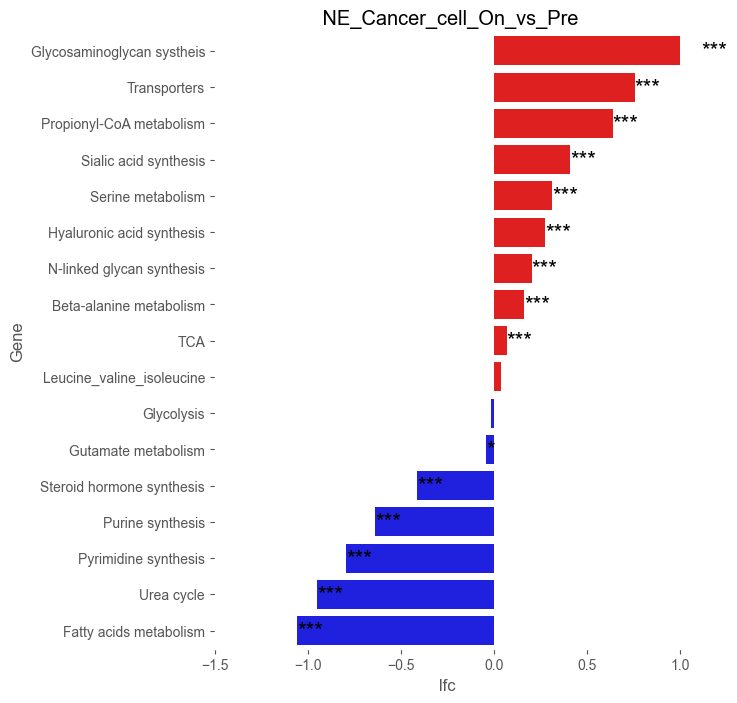

In [ ]:
#  DE analysis compare Pre and On treatment - could update for E, NE group and cell types
# TImepoint
adata_post = adata_flux_sm[adata_flux_sm.obs['expansion'].isin(['NE']) &adata_flux_sm.obs['timepoint'].isin(['Pre', 'On']) 
                   &adata_flux_sm.obs['cellType'].isin([ 'Cancer_cell']) ] #,  &adata_flux_sm.obs['LDHA_group'].isin(['Low']) 
# name_save = 'E_Pre_Cancer_cells_vsTcell_low_LDHA'
name_save = 'NE_Cancer_cell_On_vs_Pre'


key_DE = "timepoint"
sc.tl.rank_genes_groups(adata_post, key_DE, method="t-test", key_added=key_DE)# reference="Cancer_cell"


results = adata_post.uns[key_DE]
('0', '1', '2', '3', '4')

out = np.array([[0,0,0,0,0]]) 
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((results['names'][group],
                                     results['scores'][group],
                                     results['pvals_adj'][group],
                                     results['logfoldchanges'][group],
                                     np.array([group] * len(results['names'][group])).astype('object'))).T))



markers = pd.DataFrame(out[1:], columns = ['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])

from matplotlib.colors import TwoSlopeNorm
# gly_ =markers[(markers.pval_adj < 0.05)].query( 'cluster =="On"').sort_values(by="lfc", ascending=False)
gly_ =markers.query( 'cluster =="On"').sort_values(by="lfc", ascending=False)

colors = ['red' if float(lfc) >= 0 else 'blue' for lfc in gly_['lfc']]

fig, ax = plt.subplots(figsize=(6,8))
barplot = sns.barplot(
    data=gly_, 
    x="lfc", 
    y="Gene", 
    palette=colors, 
    dodge=False
)
# Add significance stars based on pval_adj
for i, (pval, lfc) in enumerate(zip(gly_['pval_adj'], gly_['lfc'])):
    pval = float(pval)
    if pval < 0.001:
        star = '***'
    elif pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    else:
        star = ''
    if star:
        ax.text(float(lfc), i, star, va='center', ha='left', color='black', fontsize=16)
plt.xlim(-1.5, 1)
plt.title(f' {name_save}')
plt.savefig(f'Validation/flc_{name_save}.pdf', dpi=300, bbox_inches='tight')


In [ ]:
#  DE analysis compare E and NE treatment - could update for Pre, On group and cell types
adata_post = adata_flux_sm[adata_flux_sm.obs['expansion'].isin(['E', 'NE']) &adata_flux_sm.obs['timepoint'].isin(['Pre']) 
                   &adata_flux_sm.obs['cellType'].isin(['Cancer_cell']) ] #, &adata_flux_sm.obs['LDHA_group'].isin(['Low']) 
name_save = 'E vs NE_pretreatment_Cancer_cells'
# print(adata_post.obs.groupby(['expansion', 'LDHA_group', 'timepoint']).count())


# DE analysis
# find DE genes by t-test
key_DE = "expansion"
sc.tl.rank_genes_groups(adata_post, key_DE, method="t-test", key_added=key_DE, reference="NE")

sc.pl.rank_genes_groups(adata_post, n_genes=15, sharey=False,
                        key=key_DE,
                        # save =f"Flux_{name_save}.pdf"
                        )
results = adata_post.uns[key_DE]
('0', '1', '2', '3', '4')

out = np.array([[0,0,0,0,0]]) 
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((results['names'][group],
                                     results['scores'][group],
                                     results['pvals_adj'][group],
                                     results['logfoldchanges'][group],
                                     np.array([group] * len(results['names'][group])).astype('object'))).T))



markers = pd.DataFrame(out[1:], columns = ['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])
# markers = markers[(markers.pval_adj < 0.05)] # & (abs(markers.lfc) > 0.5)

# markers.to_csv(f"Results/DE_flux_{name_save}_update.csv")
from matplotlib.colors import TwoSlopeNorm
gly_ =markers[(markers.pval_adj < 0.05)].query( 'cluster =="E"').sort_values(by="lfc", ascending=False)
# gly_ =markers.query( 'cluster =="On"').sort_values(by="lfc", ascending=False)

fig, ax = plt.subplots(figsize=(6,8))


barplot= sns.barplot(data=gly_, x="lfc", y="Gene", hue="lfc",palette ='Reds' , #palette=palette, 
            # order= group_order, 
              dodge=False, #hue_norm=norm
              # legend=True
              )# size="pval_adj"

barplot.legend_.remove()
norm = plt.Normalize(gly_['lfc'].min(), gly_['lfc'].max())
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
plt.title(f'On treatment {name_save}')
# for index, row in gly_.iterrows():
#     barplot.text(row['lfc'], index, round(row['lfc'], 2), color='black', ha="right", va="center")

plt.savefig(f'Final/flc_{name_save}.pdf', dpi=300, bbox_inches='tight')

In [170]:
# Correlation

# df_eda = pd.DataFrame(adata_flux_sm.X, columns=adata_flux_sm.var.index.to_list(), index= adata_flux_sm.obs.index)
df_eda = pd.DataFrame(adata_flux_sm.layers['norm'], columns=adata_flux_sm.var.index.to_list(), index= adata_flux_sm.obs.index)
# ldha_expression = pd.DataFrame(adata[:,'LDHA'].X.toarray(), columns=['LDHA_sc'], index=adata.obs['index'])
df_eda = pd.merge(df_eda, adata_flux_sm.obs[['patient_id', 'cellType', 'timepoint','expansion','LDHA', 'LDHA_group']], left_index=True, right_index=True)
# df_eda =pd.merge(df_eda,ldha_expression, left_index=True, right_index=True)

In [171]:
pathway_ = adata_flux_sm.var.index.to_list()
cell_list = ['Cancer_cell', 'T_cell']
df_eda.query('cellType in@cell_list')

,Beta-alanine metabolism,Fatty acids metabolism,Glycolysis,Glycosaminoglycan systheis,Gutamate metabolism,Hyaluronic acid synthesis,Leucine_valine_isoleucine,N-linked glycan synthesis,Propionyl-CoA metabolism,Purine synthesis,...,Steroid hormone synthesis,TCA,Transporters,Urea cycle,patient_id,cellType,timepoint,expansion,LDHA,LDHA_group
BIOKEY_13_Pre_AAACCTGCAAGAAGAG-1,0.002357,0.008153,0.012901,0.000047,0.000025,0.001429,0.003140,0.000136,0.002456,0.010700,...,0.000534,0.002045,0.000039,0.004236,BIOKEY_13,T_cell,Pre,NaN,0.768793,Low
BIOKEY_13_Pre_AAACGGGTCCGAACGC-1,0.000051,0.008144,0.000064,0.000010,0.000007,0.001304,0.003243,0.000108,0.002509,0.007632,...,0.000596,0.001828,0.000043,0.004250,BIOKEY_13,Cancer_cell,Pre,NaN,0.768793,Low
BIOKEY_13_Pre_AAACGGGTCGTAGGAG-1,0.000110,0.008150,0.011584,0.000053,0.000011,0.001339,0.003128,0.000202,0.002440,0.009756,...,0.000578,0.003215,0.000021,0.004255,BIOKEY_13,T_cell,Pre,NaN,0.768793,Low
BIOKEY_13_Pre_AAAGATGAGCAGGCTA-1,0.000051,0.008194,0.000180,0.000033,0.000019,0.001401,0.003193,0.000098,0.002452,0.007688,...,0.000532,0.002080,0.000644,0.004245,BIOKEY_13,T_cell,Pre,NaN,0.768793,Low
BIOKEY_13_Pre_AAAGATGCAAGCCGTC-1,0.000020,0.012165,0.000246,0.000023,0.000063,0.001315,0.008156,0.000064,0.009298,0.007656,...,0.000549,0.002995,0.000020,0.004235,BIOKEY_13,T_cell,Pre,NaN,0.768793,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BIOKEY_24_On_TTTGGTTCAGAGCCAA-1,0.001086,0.001447,0.014762,0.001219,0.014533,0.000431,0.001329,0.000897,0.001722,0.001443,...,0.001542,0.001531,0.005143,0.002970,BIOKEY_24,T_cell,On,NE,0.548424,Low
BIOKEY_24_On_TTTGGTTGTCCGAATT-1,0.065829,0.334359,0.018621,0.014687,0.039995,0.003063,0.489501,0.002149,0.232520,0.025787,...,0.041598,0.021848,0.009937,0.004392,BIOKEY_24,Cancer_cell,On,NE,0.548424,Low
BIOKEY_24_On_TTTGTCAAGCGTAGTG-1,0.000620,0.000121,0.074281,0.000360,0.001124,0.000041,0.000176,0.000430,0.000159,0.000089,...,0.000066,0.000088,0.003055,0.000035,BIOKEY_24,Cancer_cell,On,NE,0.548424,Low
BIOKEY_24_On_TTTGTCAAGTTCGATC-1,0.001124,0.000158,0.001469,0.000533,0.084252,0.000116,0.001946,0.000433,0.000375,0.000341,...,0.000202,0.000245,0.003183,0.000048,BIOKEY_24,Cancer_cell,On,NE,0.548424,Low


In [ ]:
# Correlation analysis at pathway level
df_plot_corr = df_eda.groupby(['patient_id', 'cellType', 'timepoint','expansion', 'LDHA_group']
                  ).mean().query('cellType =="Cancer_cell" & LDHA_group =="Low" & expansion =="E"')[pathway_+['LDHA']].corr()#
pd.DataFrame(df_plot_corr['LDHA'].sort_values()).rename(columns={'LDHA': 'correlation with LDHA'})

,correlation with LDHA
TCA,-0.661643
N-linked glycan synthesis,-0.539191
Purine synthesis,-0.512547
Pyrimidine synthesis,-0.507085
Hyaluronic acid synthesis,-0.411521
Fatty acids metabolism,-0.394635
Leucine_valine_isoleucine,-0.343778
Beta-alanine metabolism,-0.316799
Glycosaminoglycan systheis,-0.296448
Propionyl-CoA metabolism,-0.261946


In [ ]:
# Select key pathway to check correlation with LDHA
inv_pathway = ['N-linked glycan synthesis', 'Glycolysis', 'TCA', 'Fatty acids metabolism',
               'Purine synthesis', 'Pyrimidine synthesis', 'Serine metabolism']

cell_list = ['Cancer_cell', 'T_cell', 'B_cell']
check =df_eda[inv_pathway +['patient_id', 'cellType', 'timepoint','expansion', 'LDHA_group','LDHA']].groupby(
    ['patient_id', 'cellType', 'timepoint','expansion', 'LDHA_group']
                  ).mean().groupby(['LDHA_group','cellType','expansion','timepoint']).corr().query('cellType in@cell_list')['LDHA']
check#.to_csv('Results/Pahtyway_correlation_LDHA_all.csv')

LDHA_group  cellType  expansion  timepoint                           
High        B_cell    E          On         N-linked glycan synthesis   -0.128642
                                            Glycolysis                   0.837714
                                            TCA                         -0.038074
                                            Fatty acids metabolism       0.761554
                                            Purine synthesis            -0.384599
                                                                           ...   
Low         T_cell    NE         Pre        Fatty acids metabolism      -0.008571
                                            Purine synthesis             0.373723
                                            Pyrimidine synthesis         0.489721
                                            Serine metabolism            0.425596
                                            LDHA                         1.000000
Name: LDHA, Length: 192, dty

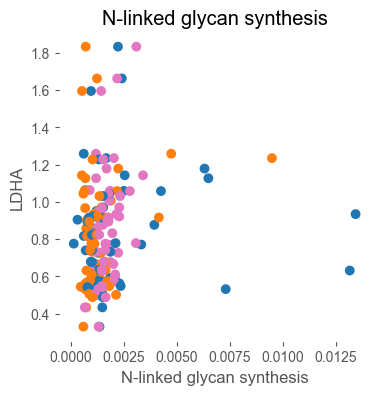

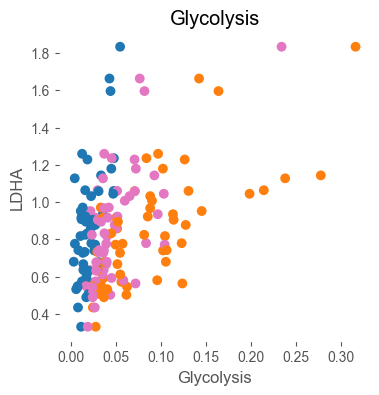

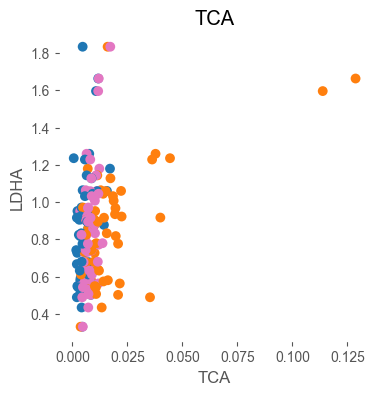

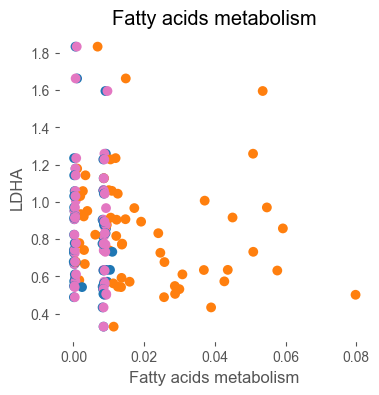

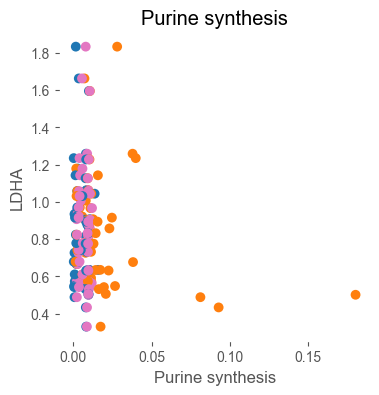

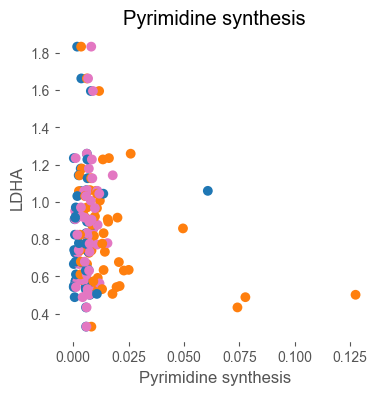

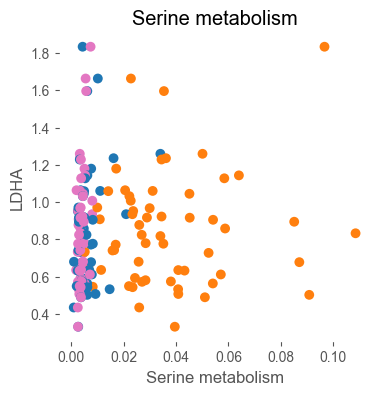

<Figure size 400x400 with 0 Axes>

In [199]:
temp_ =df_eda[inv_pathway +['patient_id', 'cellType', 'timepoint','expansion', 'LDHA_group','LDHA']].groupby(
    ['patient_id', 'cellType', 'timepoint','expansion', 'LDHA_group']
                  ).mean().query('cellType in@cell_list').dropna()
pathway =['Glycolysis']
for pathway in inv_pathway:
    # print(f'---------------{pathway}----------------')
    plt.title(f'{pathway}')
    sns.scatterplot(data = temp_, x=pathway,y='LDHA', hue='cellType', palette='tab10', 
                    linewidth=0, legend=False, s=50)
    plt.savefig(f"Plot/Scatter_{pathway}.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()


<Axes: xlabel='LDHA_group-cellType-expansion', ylabel='timepoint-level_4'>

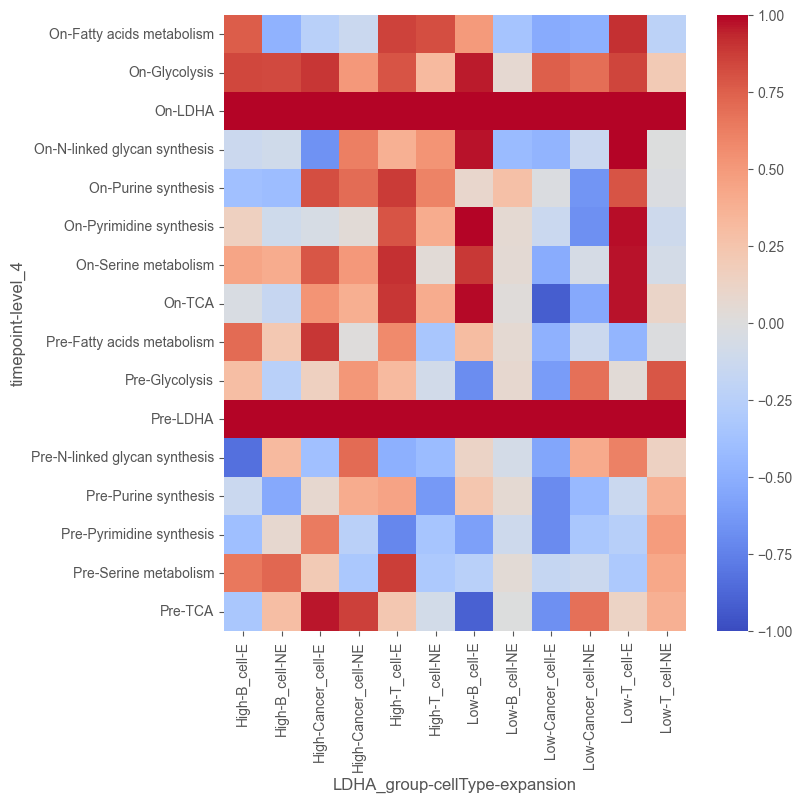

In [ ]:
# Correlation analysis
df_temp = check.reset_index()
wide_df = df_temp.pivot_table(index=['timepoint', 'level_4'], 
                              columns=['LDHA_group', 'cellType', 'expansion'], values='LDHA')
plt.figure(figsize=(8,8))
sns.heatmap(wide_df, square=True, cmap='coolwarm', vmax=1, vmin=-1)
# plt.savefig(f'Plot/correlation_ldha_pathway.pdf', dpi=300, bbox_inches='tight')

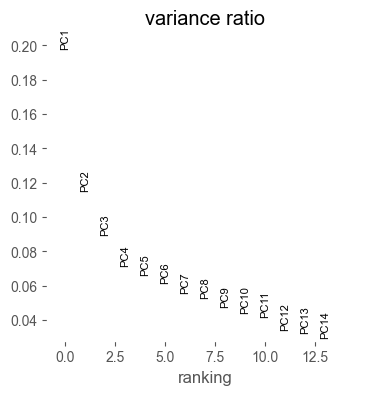

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
# UMAP
sc.tl.pca(adata_flux_sm, svd_solver='arpack', n_comps=14)
sc.pl.pca_variance_ratio(adata_flux_sm, n_pcs = 14)

#  Decide the number of neighbours based on variance ratior plot
sc.pp.neighbors(adata_flux_sm, n_pcs=5)

# Apply leiden algorithms to cluster ( it might take a while - 3-5 min)
sc.tl.leiden(adata_flux_sm, random_state=5)
sc.tl.umap(adata_flux_sm)
# sc.pl.umap(adata_flux_sm, color='timepoint',save="Pathway_PDL1_timepoint.png")


c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


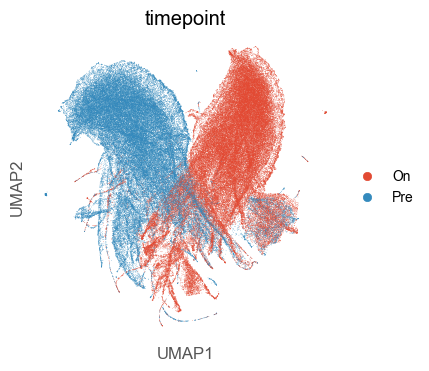

In [38]:
sc.pl.umap(adata_flux_sm, color='timepoint',save="Pathway_PDL1_timepoint_legend1.png"  )#save="Pathway_PDL1_timepoint_legend.png" legend_loc="on data" ,

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_utils.py:432: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[value_to_plot + '_colors'] = colors_list


c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


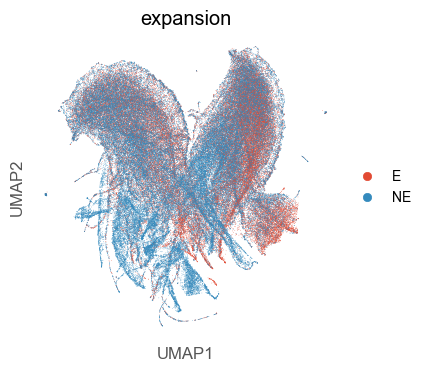

In [274]:
sc.pl.umap(adata_flux_sm[adata_flux_sm.obs['expansion'].isin(['E', 'NE']) ], color=['expansion'], #legend_loc="on data",
           save="pathway_expansion.png"
           )

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


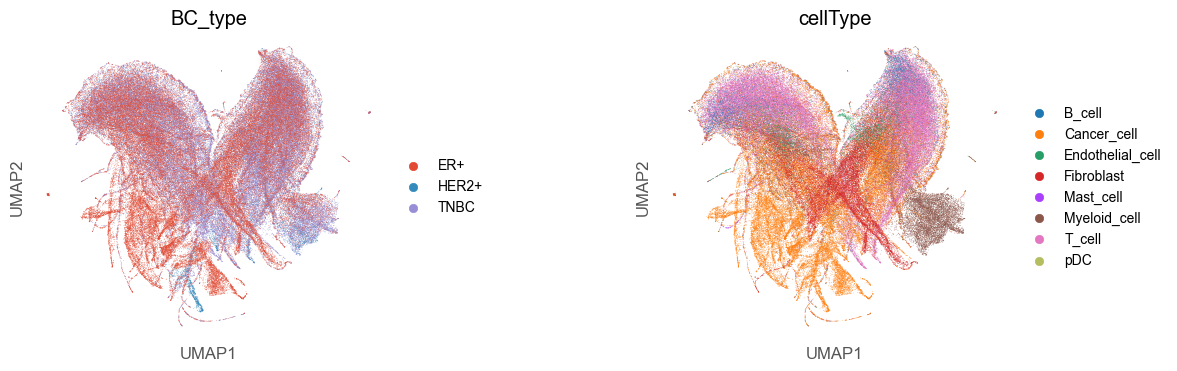

In [275]:
sc.pl.umap(adata_flux_sm, color=[ 'BC_type', "cellType"],
         #   legend_loc='on data'
            wspace=0.6,
           save="Pathway_overview_type.png"
           )

In [30]:
adata_flux_sm.var.index.to_list()

['Beta-alanine metabolism',
 'Fatty acids metabolism',
 'Glycolysis',
 'Glycosaminoglycan systheis',
 'Gutamate metabolism',
 'Hyaluronic acid synthesis',
 'Leucine_valine_isoleucine',
 'N-linked glycan synthesis',
 'Propionyl-CoA metabolism',
 'Purine synthesis',
 'Pyrimidine synthesis',
 'Serine metabolism',
 'Sialic acid synthesis',
 'Steroid hormone synthesis',
 'TCA',
 'Transporters',
 'Urea cycle']

In [39]:
adata_flux_sm

AnnData object with n_obs × n_vars = 171917 × 17
    obs: 'LDHA', 'LDHA_group', 'nCount_RNA', 'nFeature_RNA', 'patient_id', 'timepoint', 'expansion', 'BC_type', 'cellType', 'cohort', 'leiden'
    uns: 'pca', 'neighbors', 'leiden', 'umap', 'timepoint_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'scale', 'norm'
    obsp: 'distances', 'connectivities'

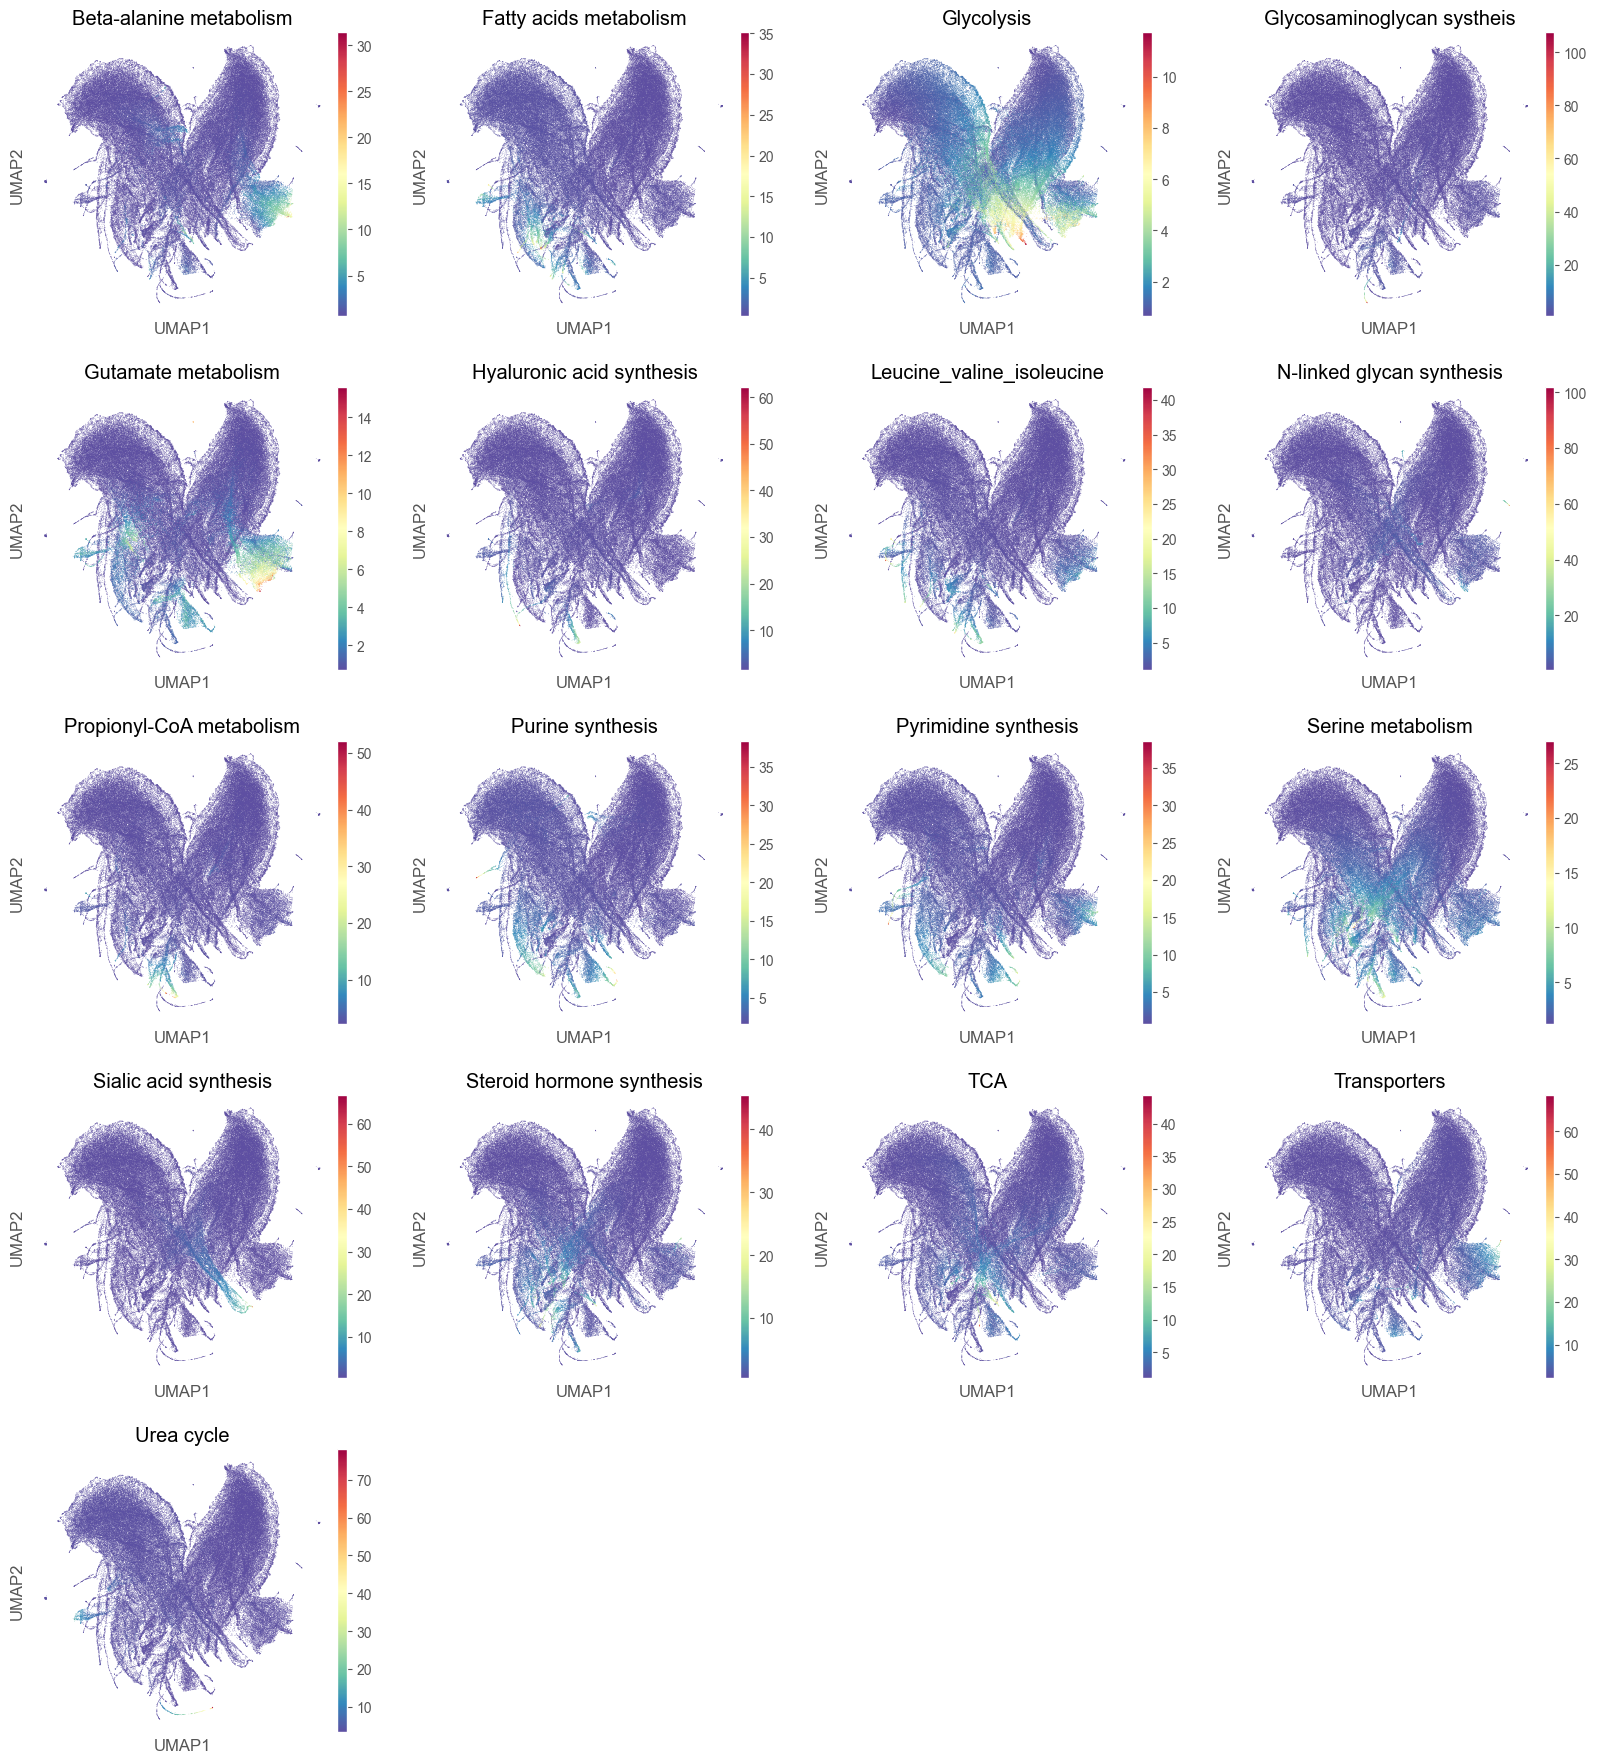

In [37]:
sc.pl.umap(adata_flux_sm, color=adata_flux_sm.var.index.to_list(),
           layer="scale",
           save="Pathway_reaction_scale.png"
           )

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


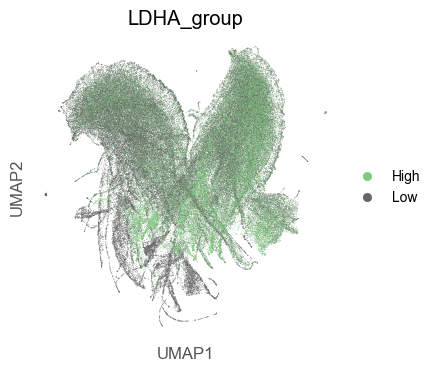

In [47]:
sc.pl.umap(adata_flux_sm, color=[ "LDHA_group"],
         #   legend_loc='on data'
            # wspace=0.6,
            palette='Accent',
           save="Pathway_LDHA-1.png"
           )

In [58]:
# DE plot
adata_post = adata_flux_sm[adata_flux_sm.obs['expansion'].isin(['E', 'NE']) &adata_flux_sm.obs['LDHA_group'].isin(['Low'])
                   &adata_flux_sm.obs['cellType'].isin(['T_cell']) ] #,  &adata_flux_sm.obs['timepoint'].isin(['On']) 
name_save = 'E vs NE_ontreatment_T_cells'
# print(adata_post.obs.groupby(['expansion', 'LDHA_group', 'timepoint']).count())


# DE analysis
# find DE genes by t-test
key_DE = "timepoint"
sc.tl.rank_genes_groups(adata_post, key_DE, method="t-test", key_added=key_DE, reference="Pre")


results = adata_post.uns[key_DE]
('0', '1', '2', '3', '4')

out = np.array([[0,0,0,0,0]]) 
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((results['names'][group],
                                     results['scores'][group],
                                     results['pvals_adj'][group],
                                     results['logfoldchanges'][group],
                                     np.array([group] * len(results['names'][group])).astype('object'))).T))



markers = pd.DataFrame(out[1:], columns = ['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])
# gly_ =markers[(markers.pval_adj < 0.05)].query( 'cluster =="E"').sort_values(by="lfc", ascending=False)

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\tools\_rank_genes_groups.py:582: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns[key_added] = {}


C:\Users\minht\AppData\Roaming\Python\Python310\site-packages\pandas\core\arraylike.py:396: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


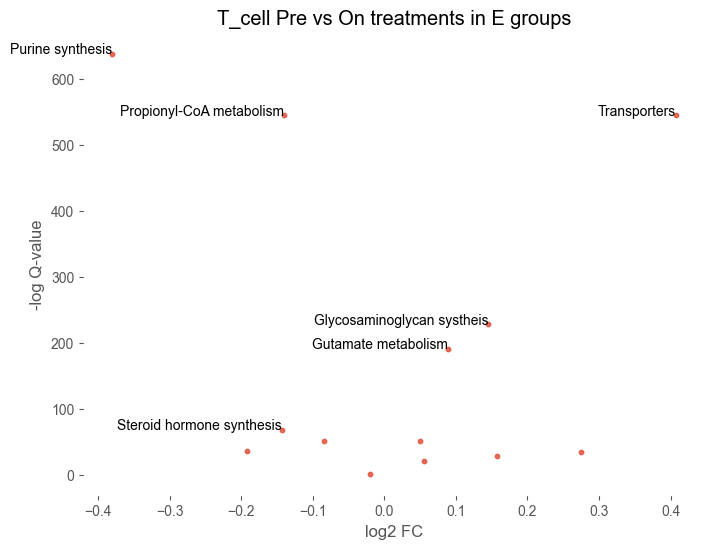

In [59]:
FDR = 0.01
LOG_FOLD_CHANGE = 1

# adata_post.uns['LDHA_group'] instead rank group
def volcano_plot(result, group_key, group_name="cell_type", groupby="label", title=None):
    # cell_type = "_".join(group_key.split("_")[1:])
    # result = sc.get.rank_genes_groups_df(adata, group=cell_type, key=group_key).copy()
    result["-logQ"] = -np.log(result["pval_adj"].astype("float"))
    lowqval_de = result.loc[abs(result["lfc"]) > LOG_FOLD_CHANGE]
    other_de = result.loc[abs(result["lfc"]) <= LOG_FOLD_CHANGE]

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.regplot(
        x=other_de["lfc"],
        y=other_de["-logQ"],
        fit_reg=False,
        scatter_kws={"s": 10},
    )
    sns.regplot(
        x=lowqval_de["lfc"],
        y=lowqval_de["-logQ"],
        fit_reg=False,
        scatter_kws={"s": 10},
    )
    ax.set_xlabel("log2 FC")
    ax.set_ylabel("-log Q-value")

    # Annotate top genes
    # top_genes = result.query('cluster =="On"').nlargest(10, 'lfc') 
    top_genes = result.query('cluster =="On"').nlargest(10, '-logQ') 
    # top_genes = result.query('Gene in@o_glycan_genes & cluster =="On"')
    for i, row in top_genes.iterrows():
        ax.annotate(row['Gene'], (row['lfc'], row['-logQ']),
                    fontsize=10, ha='right')

    if title is None:
        title = group_key.replace("_", " ")
    plt.title(title)
    # plt.savefig(f"Plot/LFC_NE_group1.pdf", bbox_inches='tight')
    plt.show()
volcano_plot(markers, "On", title="T_cell Pre vs On treatments in E groups")

In [ ]:
# EDA for pathway level
df_eda = pd.DataFrame(adata_flux_sm.layers['norm'], columns=adata_flux_sm.var.index.to_list(), index= adata_flux_sm.obs.index)
df_eda = pd.merge(df_eda, adata_flux_sm.obs[['patient_id', 'cellType', 'timepoint','expansion','LDHA', 'LDHA_group']], left_index=True, right_index=True)


---------------N-linked glycan synthesis----------------
expansion  timepoint
E          On           0.002425
           Pre          0.001459
NE         On           0.001837
           Pre          0.001159
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat  pval pval_corr reject
-------------------------------------------
  E_On  E_Pre 12.3248  0.0       0.0   True
  E_On  NE_On  6.3347  0.0       0.0   True
  E_On NE_Pre 15.5766  0.0       0.0   True
 E_Pre  NE_On -5.9979  0.0       0.0   True
 E_Pre NE_Pre  7.6751  0.0       0.0   True
 NE_On NE_Pre 10.6553  0.0       0.0   True
-------------------------------------------
P value -Bonferroni correction [4.83621876e-34 1.44809619e-09 1.04176965e-53 1.21818364e-08
 1.03228568e-13 1.16089499e-25]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1647068959.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


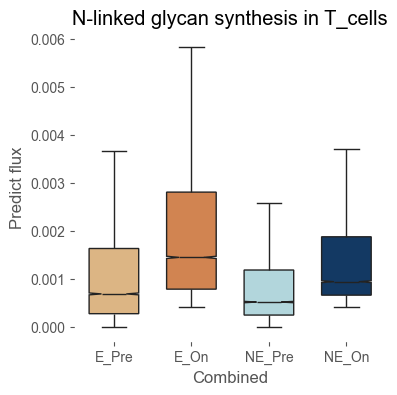

---------------Glycolysis----------------
expansion  timepoint
E          On           0.070758
           Pre          0.057335
NE         On           0.035786
           Pre          0.034901
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre 11.3093    0.0       0.0   True
  E_On  NE_On 29.9255    0.0       0.0   True
  E_On NE_Pre 32.3701    0.0       0.0   True
 E_Pre  NE_On 20.4487    0.0       0.0   True
 E_Pre NE_Pre 22.7312    0.0       0.0   True
 NE_On NE_Pre  1.1471 0.2514       1.0  False
---------------------------------------------
P value -Bonferroni correction [8.11124907e-029 5.47530546e-193 4.09734042e-225 2.79195091e-091
 2.55174402e-112 1.00000000e+000]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1647068959.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


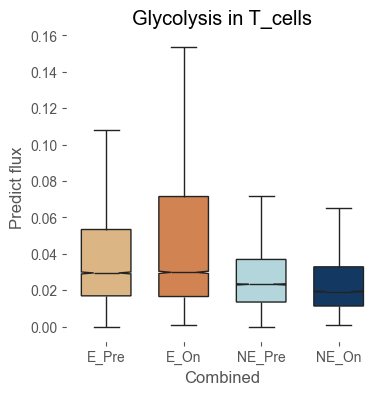

---------------TCA----------------
expansion  timepoint
E          On           0.009424
           Pre          0.009474
NE         On           0.005323
           Pre          0.007385
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre  -0.2492 0.8032       1.0  False
  E_On  NE_On  21.4356    0.0       0.0   True
  E_On NE_Pre  10.5545    0.0       0.0   True
 E_Pre  NE_On  20.9377    0.0       0.0   True
 E_Pre NE_Pre   10.195    0.0       0.0   True
 NE_On NE_Pre -12.4048    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [1.00000000e+000 2.34801865e-100 3.23404643e-025 1.34008523e-095
 1.41681814e-023 1.98017990e-034]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1647068959.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


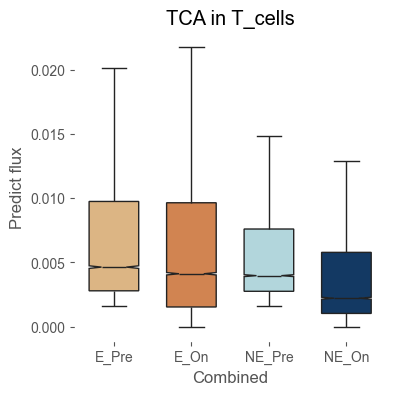

---------------Fatty acids metabolism----------------
expansion  timepoint
E          On           0.000566
           Pre          0.009089
NE         On           0.000397
           Pre          0.008781
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2    stat    pval  pval_corr reject
-----------------------------------------------
  E_On  E_Pre -104.5018    0.0       0.0   True
  E_On  NE_On    8.6113    0.0       0.0   True
  E_On NE_Pre -140.8897    0.0       0.0   True
 E_Pre  NE_On   77.6533    0.0       0.0   True
 E_Pre NE_Pre    2.4075 0.0161    0.0964  False
 NE_On NE_Pre -106.0607    0.0       0.0   True
-----------------------------------------------
P value -Bonferroni correction [0.00000000e+00 4.55506426e-17 0.00000000e+00 0.00000000e+00
 9.64323183e-02 0.00000000e+00]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1647068959.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


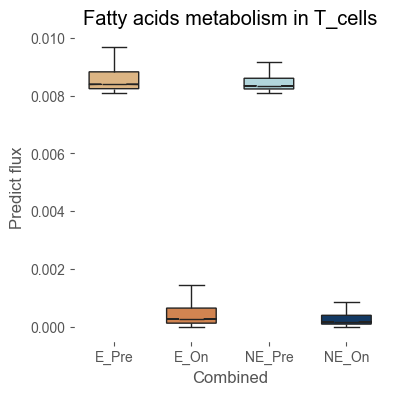

---------------Purine synthesis----------------
expansion  timepoint
E          On           0.004408
           Pre          0.010171
NE         On           0.002822
           Pre          0.009782
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre -41.5961    0.0       0.0   True
  E_On  NE_On   9.5852    0.0       0.0   True
  E_On NE_Pre   -38.67    0.0       0.0   True
 E_Pre  NE_On  46.9328    0.0       0.0   True
 E_Pre NE_Pre   3.3991 0.0007    0.0041   True
 NE_On NE_Pre -45.4462    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [0.00000000e+00 5.96969239e-21 0.00000000e+00 0.00000000e+00
 4.06415683e-03 0.00000000e+00]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1647068959.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


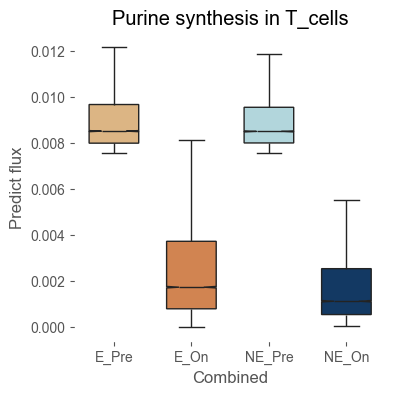

---------------Pyrimidine synthesis----------------
expansion  timepoint
E          On           0.006074
           Pre          0.009230
NE         On           0.002774
           Pre          0.007260
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval pval_corr reject
--------------------------------------------
  E_On  E_Pre -12.2497  0.0       0.0   True
  E_On  NE_On  12.0796  0.0       0.0   True
  E_On NE_Pre  -4.7124  0.0       0.0   True
 E_Pre  NE_On  27.9551  0.0       0.0   True
 E_Pre NE_Pre   9.7969  0.0       0.0   True
 NE_On NE_Pre -22.5199  0.0       0.0   True
--------------------------------------------
P value -Bonferroni correction [1.21971019e-033 9.80792947e-033 1.47541539e-005 3.63318861e-168
 7.74044260e-022 3.59994856e-110]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1647068959.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


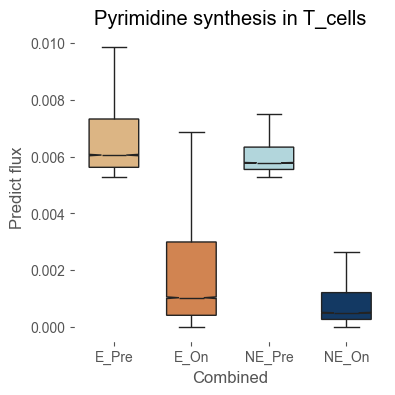

---------------Serine metabolism----------------
expansion  timepoint
E          On           0.004288
           Pre          0.003421
NE         On           0.003521
           Pre          0.002918
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  10.397    0.0       0.0   True
  E_On  NE_On 10.3923    0.0       0.0   True
  E_On NE_Pre 17.3619    0.0       0.0   True
 E_Pre  NE_On -1.0142 0.3105       1.0  False
 E_Pre NE_Pre  4.8067    0.0       0.0   True
 NE_On NE_Pre  6.7499    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [1.69229389e-24 1.78922137e-24 2.08361327e-66 1.00000000e+00
 9.26589236e-06 9.11465319e-11]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1647068959.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


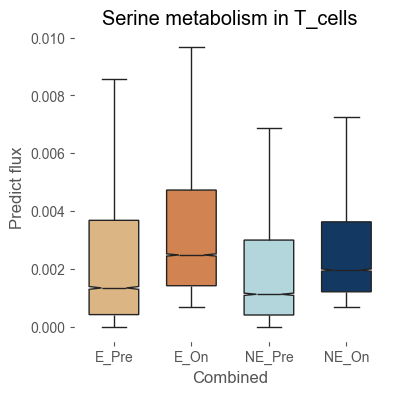

<Figure size 400x400 with 0 Axes>

In [123]:

cell_type_var = "T_cell"
pathway_list= ['TCA', ] #, 'Glycolysis_TCA' 
i = 1
for pathway in inv_pathway:
    print(f'---------------{pathway}----------------')
# pathway =  'N-linked glycan synthesis' #'O-linked glycan synthesis' #'Glycolysis_TCA'
    df_p =pd.melt(df_eda.query('cellType == @cell_type_var').dropna(axis=0), id_vars=['timepoint', 'expansion'], 
                    value_vars=[pathway],
                    var_name='Pathway', value_name='Flux')

    print(df_p.groupby(['expansion','timepoint',])['Flux'].mean())

    df_p['Combined'] =  df_p['expansion'].astype(str) +"_" +df_p['timepoint'].astype(str)
    # Performing t-test
    comp1 = mc.MultiComparison(df_p['Flux'], df_p['Combined'])

    tbl, a1, a2 = comp1.allpairtest(stats.ttest_ind, method= "bonf")
    print(tbl)
    print('P value -Bonferroni correction',a1[2])

    # hue_order = ['PR_Pre-treatment','PR_Post-treatment',  'SD_Pre-treatment','SD_Post-treatment' ] #'PR_Progression',

    ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,
                # hue_order=hue_order,
                # width_method="linear",
                # legend=None, 
                palette=['#eab676', '#e67f3c', '#abdbe3', '#063970'],
                showfliers=False, notch=True,
                )
    # sns.move_legend(ax, "upper right")
    plt.title(f'{pathway} in {cell_type_var}s')
    plt.ylabel('Predict flux')
    # plt.savefig(f"Plot_ldha/Glycolysis_Boxplot_{cell_type_var}_{pathway}.pdf", bbox_inches='tight')
    i+=1
    plt.savefig(f"Plot/Boxplot_{cell_type_var}_{pathway}_norm.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()

---------------N-linked glycan synthesis----------------
expansion  timepoint
E          On           0.001238
           Pre          0.000952
NE         On           0.001985
           Pre          0.001346
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre   3.4374 0.0006    0.0035   True
  E_On  NE_On   -6.705    0.0       0.0   True
  E_On NE_Pre  -1.2649 0.2059       1.0  False
 E_Pre  NE_On -12.3877    0.0       0.0   True
 E_Pre NE_Pre  -6.0555    0.0       0.0   True
 NE_On NE_Pre   9.7023    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [3.53402464e-03 1.23359061e-10 1.00000000e+00 2.23338770e-34
 8.50772130e-09 1.87434795e-21]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1515467668.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


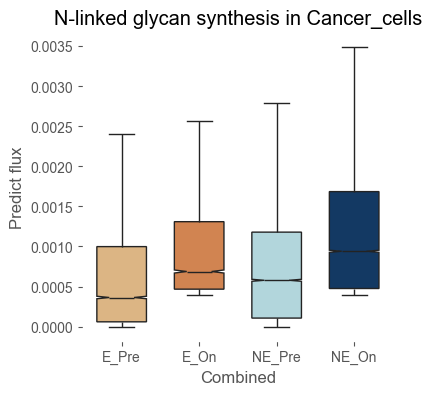

---------------Glycolysis----------------
expansion  timepoint
E          On           0.117872
           Pre          0.091363
NE         On           0.071510
           Pre          0.072299
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre 14.5211    0.0       0.0   True
  E_On  NE_On 32.5557    0.0       0.0   True
  E_On NE_Pre 27.3009    0.0       0.0   True
 E_Pre  NE_On 18.3836    0.0       0.0   True
 E_Pre NE_Pre 15.1474    0.0       0.0   True
 NE_On NE_Pre -0.8592 0.3902       1.0  False
---------------------------------------------
P value -Bonferroni correction [1.18928833e-046 4.70820596e-227 8.86087029e-161 2.78479374e-074
 7.66356583e-051 1.00000000e+000]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1515467668.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


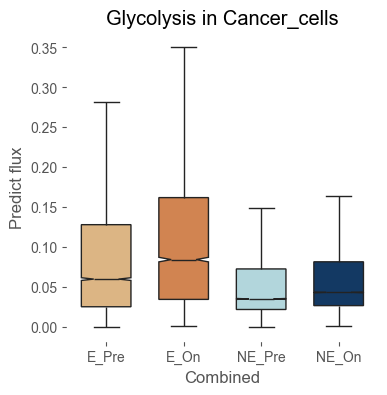

---------------TCA----------------
expansion  timepoint
E          On           0.019967
           Pre          0.024377
NE         On           0.015161
           Pre          0.014256
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -5.0555    0.0       0.0   True
  E_On  NE_On  9.3891    0.0       0.0   True
  E_On NE_Pre  11.529    0.0       0.0   True
 E_Pre  NE_On 20.9017    0.0       0.0   True
 E_Pre NE_Pre 23.0795    0.0       0.0   True
 NE_On NE_Pre  3.5383 0.0004    0.0024   True
---------------------------------------------
P value -Bonferroni correction [2.60849446e-006 3.92383040e-020 6.85092788e-030 1.53106346e-095
 5.81377088e-116 2.41863083e-003]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1515467668.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


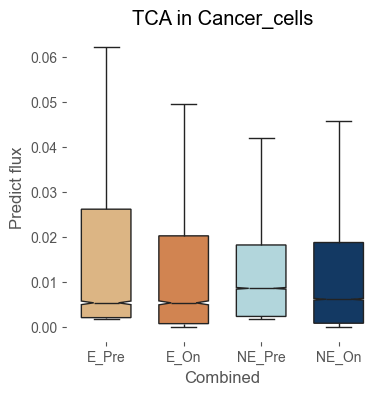

---------------Fatty acids metabolism----------------
expansion  timepoint
E          On           0.009047
           Pre          0.022321
NE         On           0.016728
           Pre          0.031150
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval pval_corr reject
--------------------------------------------
  E_On  E_Pre -17.0254  0.0       0.0   True
  E_On  NE_On -10.8459  0.0       0.0   True
  E_On NE_Pre -28.6962  0.0       0.0   True
 E_Pre  NE_On   9.3868  0.0       0.0   True
 E_Pre NE_Pre -13.6984  0.0       0.0   True
 NE_On NE_Pre -29.2047  0.0       0.0   True
--------------------------------------------
P value -Bonferroni correction [1.43322813e-063 1.43590396e-026 3.27111773e-177 3.96521267e-020
 8.61075841e-042 1.01262000e-184]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1515467668.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


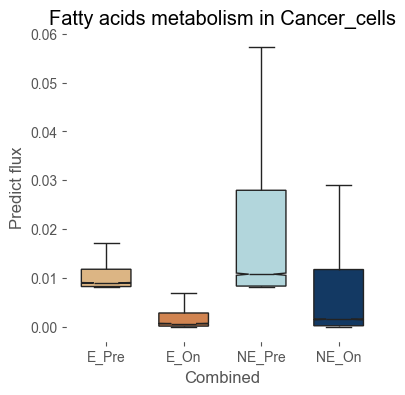

---------------Purine synthesis----------------
expansion  timepoint
E          On           0.007162
           Pre          0.014235
NE         On           0.020009
           Pre          0.031049
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval pval_corr reject
--------------------------------------------
  E_On  E_Pre -11.4616  0.0       0.0   True
  E_On  NE_On -20.6422  0.0       0.0   True
  E_On NE_Pre  -36.456  0.0       0.0   True
 E_Pre  NE_On -11.0635  0.0       0.0   True
 E_Pre NE_Pre -30.5394  0.0       0.0   True
 NE_On NE_Pre -25.2704  0.0       0.0   True
--------------------------------------------
P value -Bonferroni correction [1.68769066e-029 4.01953362e-093 3.12951603e-282 1.28546987e-027
 1.12908537e-200 5.42027964e-139]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1515467668.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


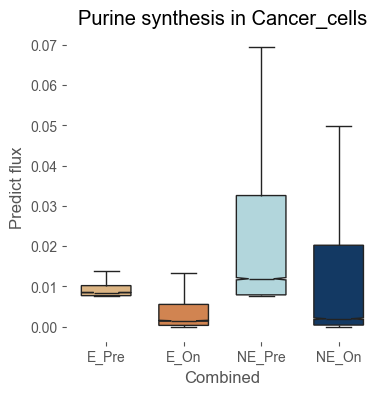

---------------Pyrimidine synthesis----------------
expansion  timepoint
E          On           0.005162
           Pre          0.014046
NE         On           0.016336
           Pre          0.027729
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval pval_corr reject
--------------------------------------------
  E_On  E_Pre -19.3962  0.0       0.0   True
  E_On  NE_On -22.4558  0.0       0.0   True
  E_On NE_Pre -39.9018  0.0       0.0   True
 E_Pre  NE_On  -5.4304  0.0       0.0   True
 E_Pre NE_Pre -29.0123  0.0       0.0   True
 NE_On NE_Pre -30.6217  0.0       0.0   True
--------------------------------------------
P value -Bonferroni correction [6.17543794e-082 7.93915101e-110 0.00000000e+000 3.39944044e-007
 1.58867196e-181 9.77014713e-203]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1515467668.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


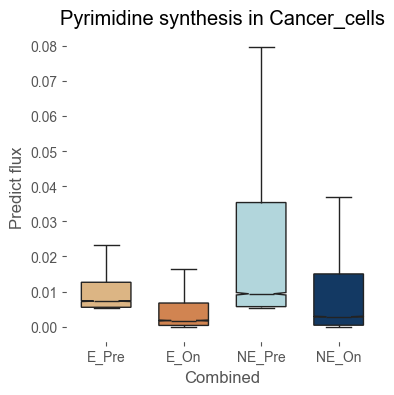

---------------Serine metabolism----------------
expansion  timepoint
E          On           0.032196
           Pre          0.030590
NE         On           0.040311
           Pre          0.032914
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre   2.0092 0.0445    0.2672  False
  E_On  NE_On  -9.5965    0.0       0.0   True
  E_On NE_Pre  -0.9646 0.3348       1.0  False
 E_Pre  NE_On -14.8805    0.0       0.0   True
 E_Pre NE_Pre  -3.9522 0.0001    0.0005   True
 NE_On NE_Pre  14.3283    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [2.67233580e-01 5.40011491e-21 1.00000000e+00 4.00363942e-49
 4.65774416e-04 1.14707714e-45]


C:\Users\minht\AppData\Local\Temp\ipykernel_17984\1515467668.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,


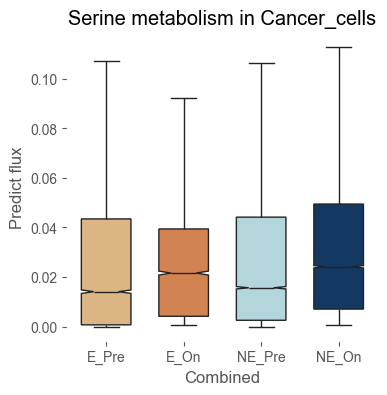

<Figure size 400x400 with 0 Axes>

In [125]:

cell_type_var = "Cancer_cell"
pathway_list= ['TCA', ] #, 'Glycolysis_TCA' 
i = 1
for pathway in inv_pathway:
    print(f'---------------{pathway}----------------')
# pathway =  'N-linked glycan synthesis' #'O-linked glycan synthesis' #'Glycolysis_TCA'
    df_p =pd.melt(df_eda.query('cellType == @cell_type_var').dropna(axis=0), id_vars=['timepoint', 'expansion'], 
                    value_vars=[pathway],
                    var_name='Pathway', value_name='Flux')

    print(df_p.groupby(['expansion','timepoint',])['Flux'].mean())

    df_p['Combined'] =  df_p['expansion'].astype(str) +"_" +df_p['timepoint'].astype(str)
    # Performing t-test
    comp1 = mc.MultiComparison(df_p['Flux'], df_p['Combined'])

    tbl, a1, a2 = comp1.allpairtest(stats.ttest_ind, method= "bonf")
    print(tbl)
    print('P value -Bonferroni correction',a1[2])

    # hue_order = ['PR_Pre-treatment','PR_Post-treatment',  'SD_Pre-treatment','SD_Post-treatment' ] #'PR_Progression',

    ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='Combined', y='Flux', gap=0.2, # whis=1, #fliersize=0,  fill=False,
                # hue_order=hue_order,
                # width_method="linear",
                # legend=None, 
                palette=['#eab676', '#e67f3c', '#abdbe3', '#063970'],
                showfliers=False, notch=True,
                )
    # sns.move_legend(ax, "upper right")
    plt.title(f'{pathway} in {cell_type_var}s')
    plt.ylabel('Predict flux')
    # plt.savefig(f"Plot_ldha/Glycolysis_Boxplot_{cell_type_var}_{pathway}.pdf", bbox_inches='tight')
    i+=1
    plt.savefig(f"Plot/Boxplot_{cell_type_var}_{pathway}_norm.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()

---------------N-linked glycan synthesis----------------
LDHA_group  expansion  timepoint
High        E          On           0.002479
                       Pre          0.001546
            NE         On           0.001849
                       Pre          0.001220
Low         E          On           0.002335
                       Pre          0.001414
            NE         On           0.001820
                       Pre          0.001109
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat   pval  pval_corr reject
-----------------------------------------------------
  HighE_On  HighE_Pre 13.6156    0.0       0.0   True
  HighE_On  HighNE_On 10.8039    0.0       0.0   True
  HighE_On HighNE_Pre  21.199    0.0       0.0   True
  HighE_On    LowE_On  1.1766 0.2394       1.0  False
  HighE_On   LowE_Pre 21.4316    0.0       0.0   True
  HighE_On   LowNE_On  6.7658    0.0       0.0   Tru

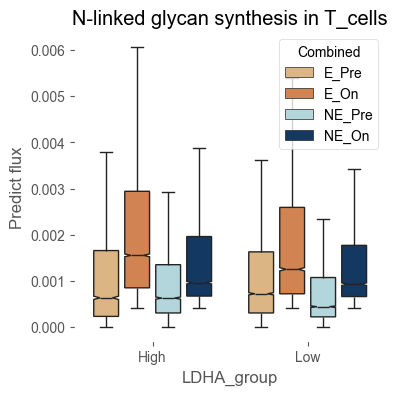

---------------Glycolysis----------------
LDHA_group  expansion  timepoint
High        E          On           0.078315
                       Pre          0.065446
            NE         On           0.037672
                       Pre          0.043698
Low         E          On           0.057977
                       Pre          0.053095
            NE         On           0.033023
                       Pre          0.027698
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre   6.2482    0.0       0.0   True
  HighE_On  HighNE_On  24.6197    0.0       0.0   True
  HighE_On HighNE_Pre  19.1296    0.0       0.0   True
  HighE_On    LowE_On  12.5909    0.0       0.0   True
  HighE_On   LowE_Pre  16.0931    0.0       0.0   True
  HighE_On   LowNE_On  23.1817    0.0       0.0   True
  Hig

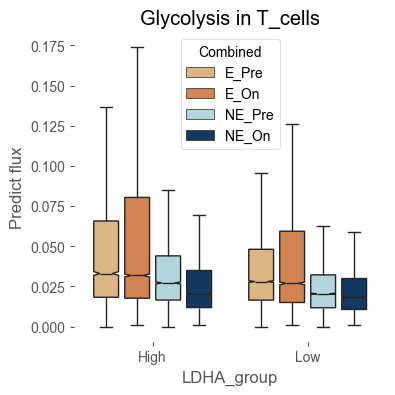

---------------TCA----------------
LDHA_group  expansion  timepoint
High        E          On           0.009624
                       Pre          0.010362
            NE         On           0.005378
                       Pre          0.008431
Low         E          On           0.009085
                       Pre          0.009010
            NE         On           0.005241
                       Pre          0.006528
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre  -2.3619 0.0182    0.5095  False
  HighE_On  HighNE_On  17.6103    0.0       0.0   True
  HighE_On HighNE_Pre    4.312    0.0    0.0005   True
  HighE_On    LowE_On   2.0568 0.0397       1.0  False
  HighE_On   LowE_Pre   2.4823 0.0131    0.3657  False
  HighE_On   LowNE_On  15.2883    0.0       0.0   True
  HighE_On  

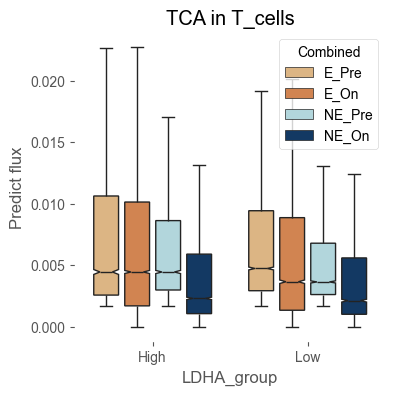

---------------Fatty acids metabolism----------------
LDHA_group  expansion  timepoint
High        E          On           0.000563
                       Pre          0.009148
            NE         On           0.000411
                       Pre          0.008859
Low         E          On           0.000571
                       Pre          0.009059
            NE         On           0.000377
                       Pre          0.008717
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2      stat    pval  pval_corr reject
-------------------------------------------------------
  HighE_On  HighE_Pre  -66.8137    0.0       0.0   True
  HighE_On  HighNE_On    6.0316    0.0       0.0   True
  HighE_On HighNE_Pre -126.1319    0.0       0.0   True
  HighE_On    LowE_On   -0.2915 0.7707       1.0  False
  HighE_On   LowE_Pre  -98.0072    0.0       0.0   True
  HighE_On   LowNE_On     7.495    0.0   

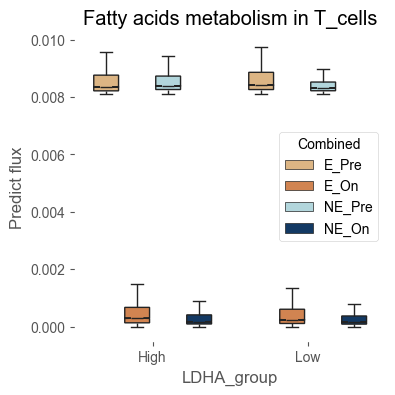

---------------Purine synthesis----------------
LDHA_group  expansion  timepoint
High        E          On           0.004410
                       Pre          0.010075
            NE         On           0.002688
                       Pre          0.010149
Low         E          On           0.004404
                       Pre          0.010221
            NE         On           0.003018
                       Pre          0.009481
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre -25.5381    0.0       0.0   True
  HighE_On  HighNE_On   9.1738    0.0       0.0   True
  HighE_On HighNE_Pre -27.8465    0.0       0.0   True
  HighE_On    LowE_On   0.0343 0.9726       1.0  False
  HighE_On   LowE_Pre -33.3476    0.0       0.0   True
  HighE_On   LowNE_On   5.1089    0.0       0.0   True

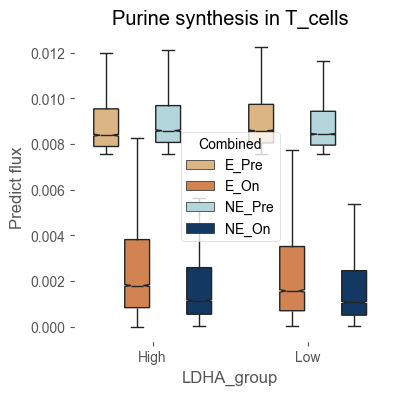

---------------Pyrimidine synthesis----------------
LDHA_group  expansion  timepoint
High        E          On           0.005355
                       Pre          0.010524
            NE         On           0.003172
                       Pre          0.008396
Low         E          On           0.007289
                       Pre          0.008554
            NE         On           0.002192
                       Pre          0.006329
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre -13.8247    0.0       0.0   True
  HighE_On  HighNE_On   6.9281    0.0       0.0   True
  HighE_On HighNE_Pre  -9.0431    0.0       0.0   True
  HighE_On    LowE_On   -5.272    0.0       0.0   True
  HighE_On   LowE_Pre -11.5804    0.0       0.0   True
  HighE_On   LowNE_On   8.9485    0.0       0.0   

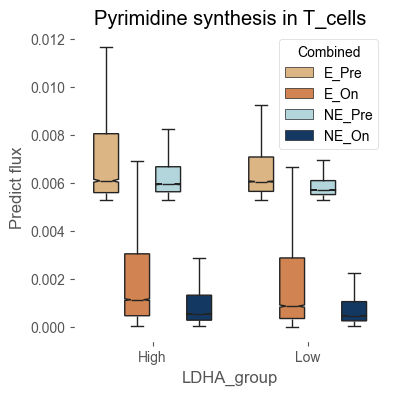

---------------Serine metabolism----------------
LDHA_group  expansion  timepoint
High        E          On           0.004315
                       Pre          0.003543
            NE         On           0.003439
                       Pre          0.003195
Low         E          On           0.004242
                       Pre          0.003357
            NE         On           0.003641
                       Pre          0.002692
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat   pval  pval_corr reject
-----------------------------------------------------
  HighE_On  HighE_Pre  6.8544    0.0       0.0   True
  HighE_On  HighNE_On  9.5679    0.0       0.0   True
  HighE_On HighNE_Pre 10.9791    0.0       0.0   True
  HighE_On    LowE_On  0.7887 0.4303       1.0  False
  HighE_On   LowE_Pre  8.7597    0.0       0.0   True
  HighE_On   LowNE_On  6.0374    0.0       0.0   True
  High

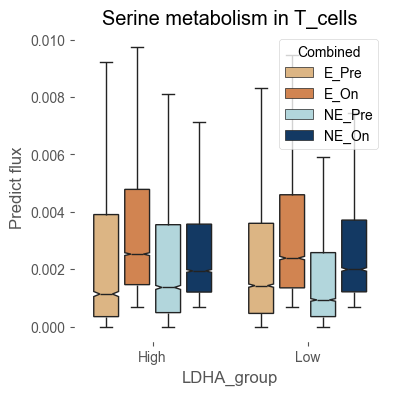

<Figure size 400x400 with 0 Axes>

In [117]:

cell_type_var = "T_cell"
pathway_list= ['TCA', ] #, 'Glycolysis_TCA' 
i = 1
for pathway in inv_pathway:
    print(f'---------------{pathway}----------------')
# pathway =  'N-linked glycan synthesis' #'O-linked glycan synthesis' #'Glycolysis_TCA'
    df_p =pd.melt(df_eda.query('cellType == @cell_type_var').dropna(axis=0), id_vars=['LDHA_group', 'timepoint', 'expansion'], 
                    value_vars=[pathway],
                    var_name='Pathway', value_name='Flux')

    print(df_p.groupby(['LDHA_group', 'expansion','timepoint',])['Flux'].mean())

    df_p['Combined'] =  df_p['expansion'].astype(str) +"_" +df_p['timepoint'].astype(str)
    df_p['Combined1'] = df_p['LDHA_group'].astype(str) + df_p['expansion'].astype(str) +"_" +df_p['timepoint'].astype(str)
    # Performing t-test
    comp1 = mc.MultiComparison(df_p['Flux'], df_p['Combined1'])

    tbl, a1, a2 = comp1.allpairtest(stats.ttest_ind, method= "bonf")
    print(tbl)
    print('P value -Bonferroni correction',a1[2])

    # hue_order = ['PR_Pre-treatment','PR_Post-treatment',  'SD_Pre-treatment','SD_Post-treatment' ] #'PR_Progression',

    ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='LDHA_group', y='Flux', hue='Combined',   gap=0.2, # whis=1, #fliersize=0,  fill=False,
                # hue_order=hue_order,
                # width_method="linear",
                # legend=None, 
                palette=['#eab676', '#e67f3c', '#abdbe3', '#063970'],
                showfliers=False, notch=True,
                )
    # sns.move_legend(ax, "upper right")
    plt.title(f'{pathway} in {cell_type_var}s')
    plt.ylabel('Predict flux')
    # plt.savefig(f"Plot_ldha/Glycolysis_Boxplot_{cell_type_var}_{pathway}.pdf", bbox_inches='tight')
    i+=1
    plt.savefig(f"Plot_ldha/Boxplot_{cell_type_var}_{pathway}_norm.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()

---------------N-linked glycan synthesis----------------
LDHA_group  expansion  timepoint
High        E          On           0.001379
                       Pre          0.000891
            NE         On           0.004203
                       Pre          0.002133
Low         E          On           0.001074
                       Pre          0.000991
            NE         On           0.001365
                       Pre          0.001008
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre    4.208    0.0    0.0007   True
  HighE_On  HighNE_On -15.0341    0.0       0.0   True
  HighE_On HighNE_Pre  -6.9928    0.0       0.0   True
  HighE_On    LowE_On   2.0801 0.0376       1.0  False
  HighE_On   LowE_Pre   2.7291 0.0064    0.1782  False
  HighE_On   LowNE_On   0.0908 0.9276       1

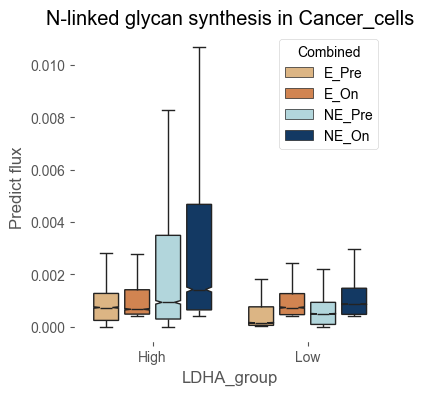

---------------Glycolysis----------------
LDHA_group  expansion  timepoint
High        E          On           0.130080
                       Pre          0.138356
            NE         On           0.093816
                       Pre          0.137036
Low         E          On           0.103606
                       Pre          0.061087
            NE         On           0.065281
                       Pre          0.044532
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre  -2.6259 0.0087    0.2426  False
  HighE_On  HighNE_On  12.1115    0.0       0.0   True
  HighE_On HighNE_Pre  -2.1529 0.0314     0.878  False
  HighE_On    LowE_On   7.9371    0.0       0.0   True
  HighE_On   LowE_Pre  29.2799    0.0       0.0   True
  HighE_On   LowNE_On   36.497    0.0       0.0   True
  Hig

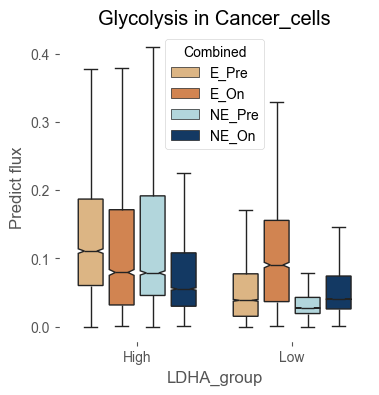

---------------TCA----------------
LDHA_group  expansion  timepoint
High        E          On           0.026295
                       Pre          0.043537
            NE         On           0.028134
                       Pre          0.022045
Low         E          On           0.012571
                       Pre          0.012033
            NE         On           0.011539
                       Pre          0.010916
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre -10.3503    0.0       0.0   True
  HighE_On  HighNE_On  -1.4856 0.1374       1.0  False
  HighE_On HighNE_Pre   4.2033    0.0    0.0007   True
  HighE_On    LowE_On   9.8118    0.0       0.0   True
  HighE_On   LowE_Pre  14.2051    0.0       0.0   True
  HighE_On   LowNE_On  23.8578    0.0       0.0   True
  HighE_On  

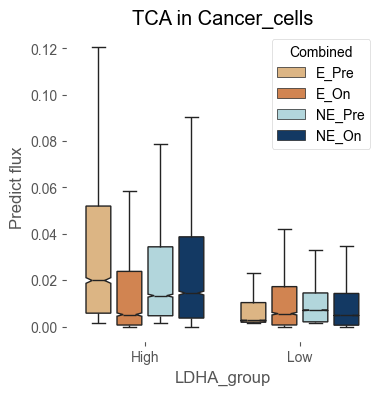

---------------Fatty acids metabolism----------------
LDHA_group  expansion  timepoint
High        E          On           0.010192
                       Pre          0.017374
            NE         On           0.016123
                       Pre          0.032357
Low         E          On           0.007710
                       Pre          0.025508
            NE         On           0.016896
                       Pre          0.030632
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre  -7.9229    0.0       0.0   True
  HighE_On  HighNE_On  -5.3057    0.0       0.0   True
  HighE_On HighNE_Pre -19.1573    0.0       0.0   True
  HighE_On    LowE_On   2.5957 0.0095    0.2651  False
  HighE_On   LowE_Pre -12.8996    0.0       0.0   True
  HighE_On   LowNE_On  -7.1739    0.0       0.0 

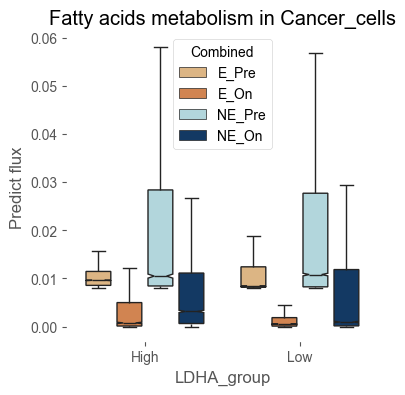

---------------Purine synthesis----------------
LDHA_group  expansion  timepoint
High        E          On           0.008038
                       Pre          0.010377
            NE         On           0.016734
                       Pre          0.021811
Low         E          On           0.006140
                       Pre          0.016721
            NE         On           0.020923
                       Pre          0.035011
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre  -5.5529    0.0       0.0   True
  HighE_On  HighNE_On -13.5833    0.0       0.0   True
  HighE_On HighNE_Pre -28.4206    0.0       0.0   True
  HighE_On    LowE_On   2.9808 0.0029    0.0809  False
  HighE_On   LowE_Pre  -8.3586    0.0       0.0   True
  HighE_On   LowNE_On -14.2622    0.0       0.0   True

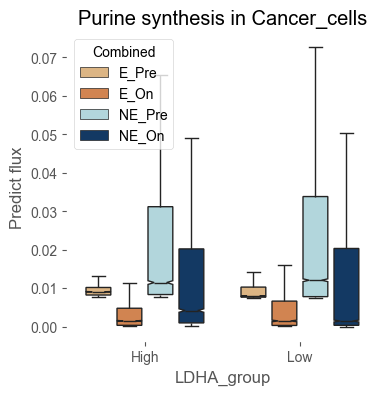

---------------Pyrimidine synthesis----------------
LDHA_group  expansion  timepoint
High        E          On           0.004629
                       Pre          0.012271
            NE         On           0.009970
                       Pre          0.021236
Low         E          On           0.005785
                       Pre          0.015189
            NE         On           0.018113
                       Pre          0.030513
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat   pval pval_corr reject
----------------------------------------------------
  HighE_On  HighE_Pre -28.6538  0.0       0.0   True
  HighE_On  HighNE_On -14.0107  0.0       0.0   True
  HighE_On HighNE_Pre -27.5304  0.0       0.0   True
  HighE_On    LowE_On  -4.2503  0.0    0.0006   True
  HighE_On   LowE_Pre -13.7776  0.0       0.0   True
  HighE_On   LowNE_On -18.3536  0.0       0.0   True
  HighE_On 

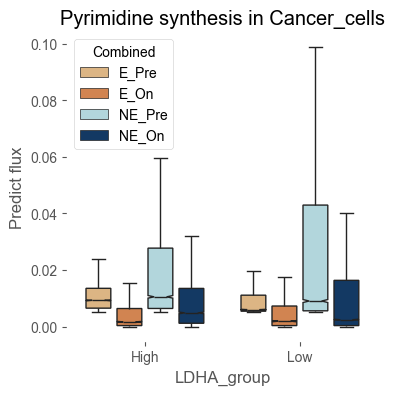

---------------Serine metabolism----------------
LDHA_group  expansion  timepoint
High        E          On           0.034278
                       Pre          0.034286
            NE         On           0.030406
                       Pre          0.051706
Low         E          On           0.029762
                       Pre          0.028209
            NE         On           0.043077
                       Pre          0.024854
Name: Flux, dtype: float64
Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.00, alphacBonf=0.002
  group1     group2     stat    pval  pval_corr reject
------------------------------------------------------
  HighE_On  HighE_Pre  -0.0075 0.9941       1.0  False
  HighE_On  HighNE_On   3.4302 0.0006     0.017   True
  HighE_On HighNE_Pre -13.5806    0.0       0.0   True
  HighE_On    LowE_On   3.4473 0.0006     0.016   True
  HighE_On   LowE_Pre   4.8875    0.0       0.0   True
  HighE_On   LowNE_On  -7.2921    0.0       0.0   Tru

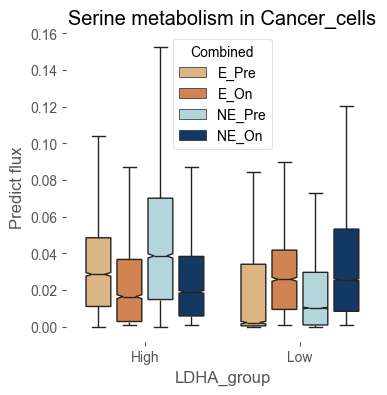

<Figure size 400x400 with 0 Axes>

In [118]:

cell_type_var = "Cancer_cell"
pathway_list= ['TCA', ] #, 'Glycolysis_TCA' 
i = 1
for pathway in inv_pathway:
    print(f'---------------{pathway}----------------')
# pathway =  'N-linked glycan synthesis' #'O-linked glycan synthesis' #'Glycolysis_TCA'
    df_p =pd.melt(df_eda.query('cellType == @cell_type_var').dropna(axis=0), id_vars=['LDHA_group', 'timepoint', 'expansion'], 
                    value_vars=[pathway],
                    var_name='Pathway', value_name='Flux')

    print(df_p.groupby(['LDHA_group', 'expansion','timepoint',])['Flux'].mean())

    df_p['Combined'] =  df_p['expansion'].astype(str) +"_" +df_p['timepoint'].astype(str)
    df_p['Combined1'] = df_p['LDHA_group'].astype(str) + df_p['expansion'].astype(str) +"_" +df_p['timepoint'].astype(str)
    # Performing t-test
    comp1 = mc.MultiComparison(df_p['Flux'], df_p['Combined1'])

    tbl, a1, a2 = comp1.allpairtest(stats.ttest_ind, method= "bonf")
    print(tbl)
    print('P value -Bonferroni correction',a1[2])

    # hue_order = ['PR_Pre-treatment','PR_Post-treatment',  'SD_Pre-treatment','SD_Post-treatment' ] #'PR_Progression',

    ax = sns.boxplot(data=df_p.query('Pathway ==@pathway'),x ='LDHA_group', y='Flux', hue='Combined',   gap=0.2, # whis=1, #fliersize=0,  fill=False,
                # hue_order=hue_order,
                # width_method="linear",
                # legend=None, 
                palette=['#eab676', '#e67f3c', '#abdbe3', '#063970'],
                showfliers=False, notch=True,
                )
    # sns.move_legend(ax, "upper right")
    plt.title(f'{pathway} in {cell_type_var}s')
    plt.ylabel('Predict flux')
    # plt.savefig(f"Plot_ldha/Glycolysis_Boxplot_{cell_type_var}_{pathway}.pdf", bbox_inches='tight')
    i+=1
    plt.savefig(f"Plot_ldha/Boxplot_{cell_type_var}_{pathway}_norm.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()

<h3> Flux analysis  -Reaction level

In [37]:
flux = pd.concat([flux_1, flux_2], axis=0).abs()
flux.head()

# Check data
print("Sample size before preprocesing", flux.shape)
print(flux.isna().sum().sum())
print(flux.index.duplicated().sum())

# Remove small variance
var_cal = flux.var()
flux = flux.loc[:, var_cal > 1e-6]
print("Sample size", flux.shape)
flux.var(axis=1).min()

# Super_module :Aggreate by mean 
flux_sm = pd.merge(module_name['Supermodule_name'], flux.T, left_index=True, right_index=True).groupby('Supermodule_name').mean().T

#  Map name
# module_name['Name'] = module_name['Compound_IN_name'] + "_" + module_name['Compound_OUT_name']
map_id =  dict(zip(module_name.index.astype(str), module_name["Module_name"]))
flux = flux.rename(columns=map_id)

# Convert anadata
adata_flux = sc.AnnData(flux.loc[cell_type.index])

adata_flux.obs = adata_flux.obs.merge(cell_type, left_index=True, right_index=True)


Sample size before preprocesing (175942, 168)
0
0
Sample size (175942, 61)


In [43]:
# glycolysis_reactions = ['G6P_G3P', 'G3P_3PD', '3PD_Pyruvate', 'Pyruvate_Lactate']
# o_glycan_reactions = ['Dolichyl phosphate D-mannose+Protein serine_(Gal)1 (GlcNAc)1 (Man)1 (Ser/Thr)1'] # M_125
n_glycan_reactions = ['Acetyl-CoA_(E,E)-Farnesyl-PP', 'Dolichyl phosphate_(GlcNAc)4 (Man)3 (Asn)1', '(Glc)3 (GlcNAc)2 (Man)9 (Asn)1_(GlcNAc)4 (Man)3 (Asn)1',
'(GlcNAc)4 (Man)3 (Asn)1_(Gal)2 (GlcNAc)4 (LFuc)1 (Man)3 (Neu5Ac)2 (Asn)1', '(GlcNAc)4 (Man)3 (Asn)1_(GlcNAc)7 (Man)3 (Asn)1'] #M_113, M_119, M_121, M_122, M_123


c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\anndata\_core\anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing 

Text(0.5, 1.0, 'E_Pre_Tcells_vs_cancer_N_glycan')

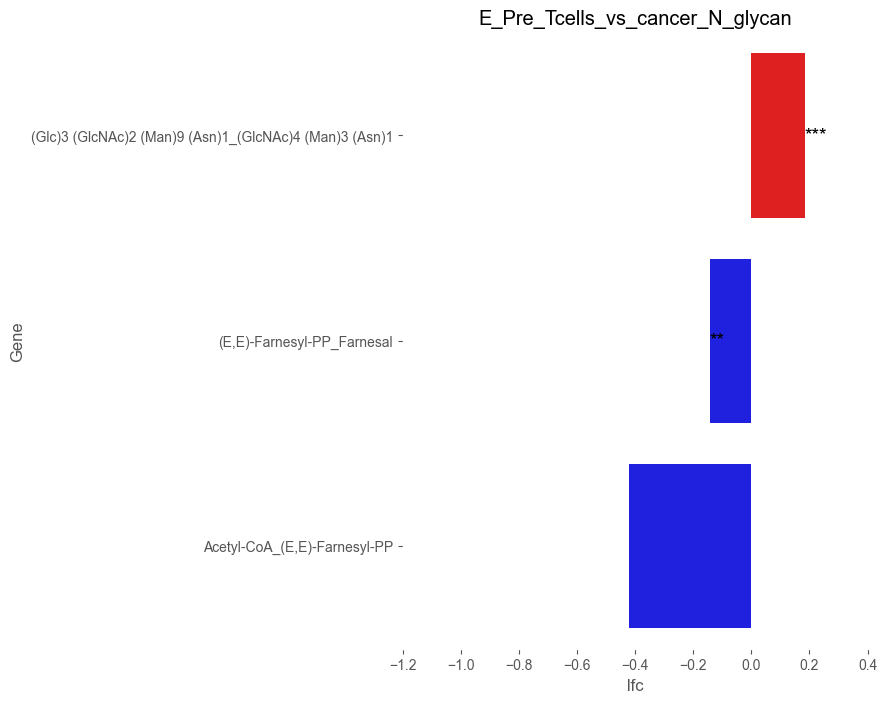

In [ ]:
# DE analysis

# Select subset: post-treatment
# Cells: T_cell, Cancer_cell               
adata_post = adata_flux[adata_flux.obs['expansion'].isin(['E']) &adata_flux.obs['timepoint'].isin(['Pre']) 
                   &adata_flux.obs['cellType'].isin(['T_cell', 'Cancer_cell'])  ] #, 
name_save = 'E_Pre_Tcells_vs_cancer_N_glycan'


# DE analysis
# find DE genes by t-test
key_DE = "cellType"
sc.tl.rank_genes_groups(adata_post, key_DE, method="t-test", key_added=key_DE)

# sc.pl.rank_genes_groups(adata_post, n_genes=15, sharey=False,
#                         key=key_DE,
#                         # save =f"Flux_{name_save}.pdf"
#                         )

results = adata_post.uns[key_DE]
('0', '1', '2', '3', '4')

out = np.array([[0,0,0,0,0]]) 
for group in results['names'].dtype.names:
    out = np.vstack((out, np.vstack((results['names'][group],
                                     results['scores'][group],
                                     results['pvals_adj'][group],
                                     results['logfoldchanges'][group],
                                     np.array([group] * len(results['names'][group])).astype('object'))).T))



markers = pd.DataFrame(out[1:], columns = ['Gene', 'scores', 'pval_adj', 'lfc', 'cluster'])
# n_glycan_reactions =['(E,E)-Farnesyl-PP_Dolichyl phosphate', 'Dolichyl phosphate_Dolichyl phosphate D-mannose',
#                      'Dolichyl phosphate_(GlcNAc)4 (Man)3 (Asn)1', '(GlcNAc)4 (Man)3 (Asn)1_(Gal)2 (GlcNAc)4 (LFuc)1 (Man)3 (Neu5Ac)2 (Asn)1',
#                      '(GlcNAc)4 (Man)3 (Asn)1_(GlcNAc)7 (Man)3 (Asn)1']
n_glycan_reactions=['(E,E)-Farnesyl-PP_Farnesal', 'Acetyl-CoA_(E,E)-Farnesyl-PP', '(Glc)3 (GlcNAc)2 (Man)9 (Asn)1_(GlcNAc)4 (Man)3 (Asn)1']

glycolysis_reactions = ['G6P_G3P', 'G3P_3PD', '3PD_Pyruvate', 'Pyruvate_Lactate']
gly_ =markers.query('Gene in@n_glycan_reactions & cluster =="T_cell"').sort_values(by="lfc", ascending=False)
# gly_ =markers[(markers.pval_adj < 0.05) &(markers.lfc.abs() >0.3)].query( 'cluster =="T_cell"').sort_values(by="lfc", ascending=False)


colors = ['red' if float(lfc) >= 0 else 'blue' for lfc in gly_['lfc']]

fig, ax = plt.subplots(figsize=(6,8))
barplot = sns.barplot(
    data=gly_, 
    x="lfc", 
    y="Gene", 
    palette=colors, 
    dodge=False
)
# Add significance stars based on pval_adj
for i, (pval, lfc) in enumerate(zip(gly_['pval_adj'], gly_['lfc'])):
    pval = float(pval)
    if pval < 0.001:
        star = '***'
    elif pval < 0.01:
        star = '**'
    elif pval < 0.05:
        star = '*'
    else:
        star = ''
    if star:
        ax.text(float(lfc), i, star, va='center', ha='left', color='black', fontsize=14)
plt.xlim(-1.2, 0.4)
plt.title(f'{name_save}')
# plt.savefig(f'Validation/flc_{name_save}1.pdf', dpi=300, bbox_inches='tight')

C:\Users\minht\AppData\Local\Temp\ipykernel_6084\2733918574.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


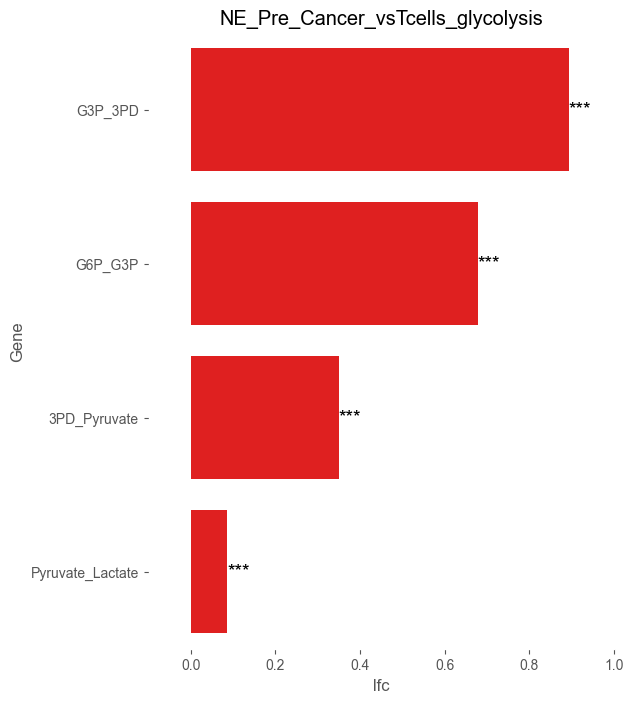

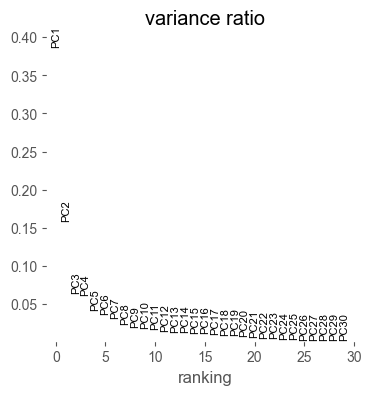

In [238]:
# 3.1 PCA
sc.tl.pca(adata_flux, svd_solver='arpack', n_comps=30)
sc.pl.pca_variance_ratio(adata_flux, n_pcs = 30)
#  Decide the number of neighbours based on variance ratior plot
sc.pp.neighbors(adata_flux, n_pcs=10)

# Apply leiden algorithms to cluster ( it might take a while - 3-5 min)
sc.tl.leiden(adata_flux, random_state=5)
sc.tl.umap(adata_flux)

In [239]:
adata_flux

AnnData object with n_obs × n_vars = 171917 × 61
    obs: 'LDHA', 'LDHA_group', 'nCount_RNA', 'nFeature_RNA', 'patient_id', 'timepoint', 'expansion', 'BC_type', 'cellType', 'cohort', 'leiden'
    uns: 'pca', 'neighbors', 'leiden', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


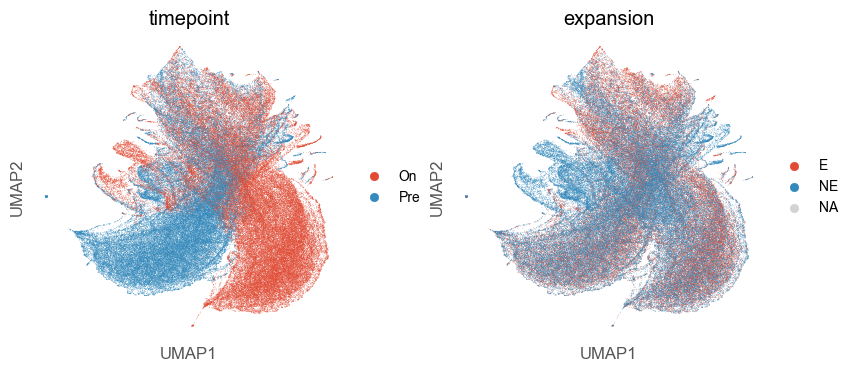

In [246]:
sc.pl.umap(adata_flux, color=['timepoint','expansion' ], save='reaction_umap.png')

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


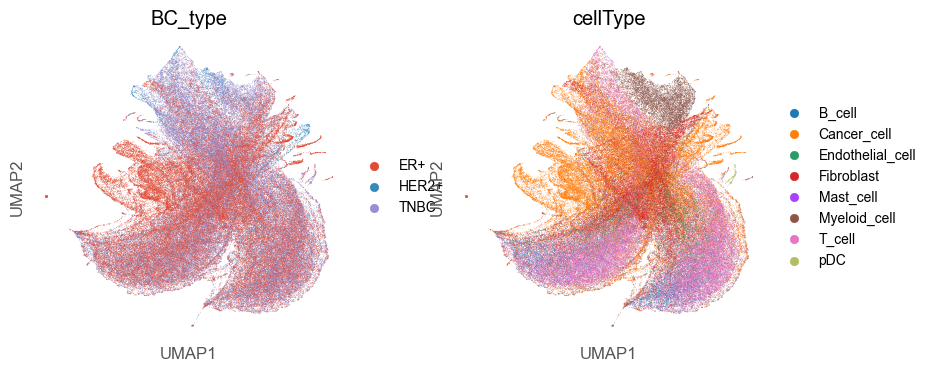

In [242]:
sc.pl.umap(adata_flux, color=['BC_type','cellType' ]) #legend_loc='on data'

c:\Users\minht\anaconda3\envs\pytorch-gpu\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


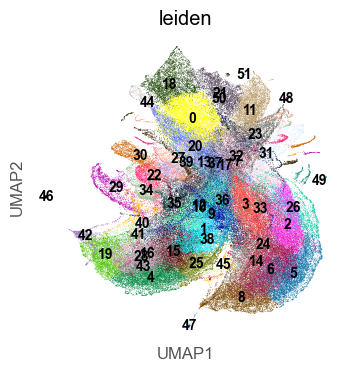

In [243]:
sc.pl.umap(adata_flux, color='leiden',legend_loc='on data')

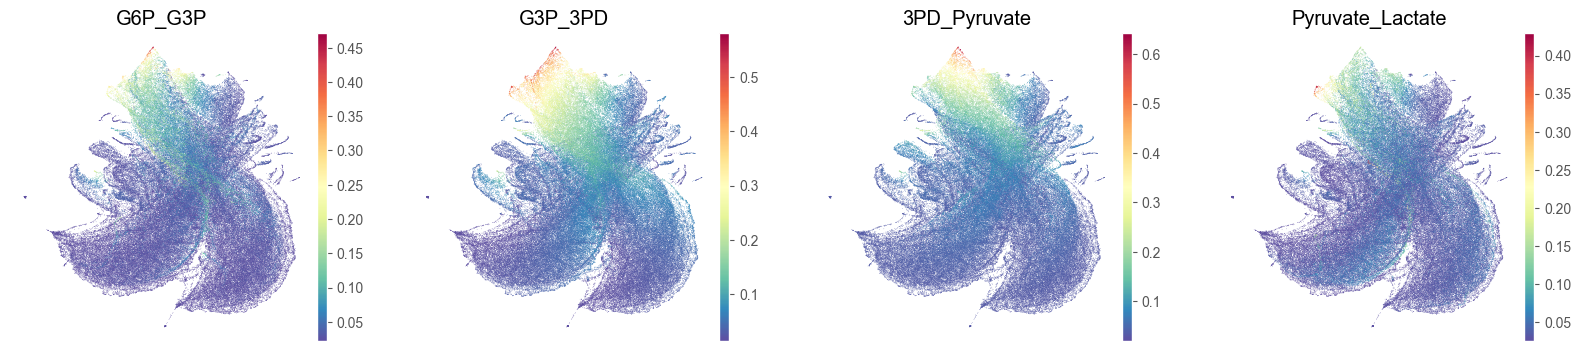

In [245]:
sc.pl.embedding(
    adata_flux,
    basis="umap",
    # layer="MAGIC_imputed_data",
    color= glycolysis_reactions,
    save="glycoglysis_umap.png",
    frameon=False,
)
plt.show()

In [36]:
adata

AnnData object with n_obs × n_vars = 175942 × 1519
    obs: 'nCount_RNA', 'nFeature_RNA', 'patient_id', 'timepoint', 'expansion', 'BC_type', 'cellType', 'cohort', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'leiden'
    var: 'gene', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'Selected_gene'
    uns: 'log1p', 'timepoint', 'hvg', 'pca', 'neighbors', 'leiden', 'umap', 'timepoint_colors', 'expansion_colors', 'BC_type_colors', 'cellType_colors', 'leiden_colors', 'DM_EigenValues'
    obsm: 'X_pca', 'X_umap', 'DM_EigenVectors', 'DM_EigenVectors_multiscaled'

In [68]:
adata.obs['timepoint'] = pd.Categorical(adata.obs['timepoint'], categories=['Pre', 'On'], ordered=True)

In [79]:
glyco_list1 =[ 'HK1',    'HK2',    'HK3',
  'PFKL',   'PFKM',      
 'PFKP', 'PGK1',  'TPI1',
 'ENO2',  'ENO3',  'PGAM1', 'PGAM2',
 'PKM',  'BSG',
 'LDHB',  'LDHA',
  'SLC2A1','SLC16A1', 'SLC16A3'
#  'ALDOA', 
]

In [40]:
# Already log norm
sc_ge = pd.DataFrame(data=adata.X.todense(), 
             index=adata.obs_names, columns=adata.var_names)

T-statistic: 21.78214917596116, P-value: 9.442808766300047e-105
timepoint
On     2.677049
Pre    2.472685
Name: Flux, dtype: float64


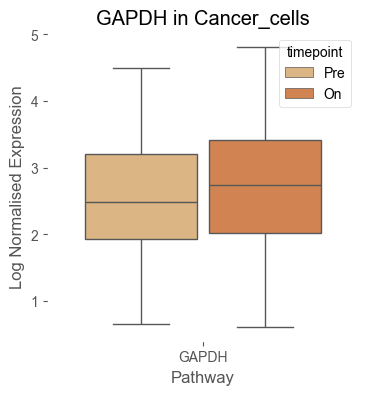

T-statistic: 4.627796296141385, P-value: 3.7041272082229127e-06
timepoint
On     0.113056
Pre    0.102198
Name: Flux, dtype: float64


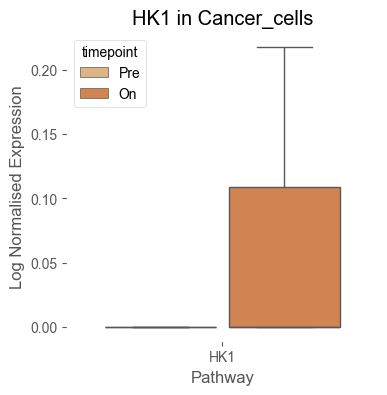

T-statistic: -1.0786064475031172, P-value: 0.2807678994485965
timepoint
On     0.055327
Pre    0.057462
Name: Flux, dtype: float64


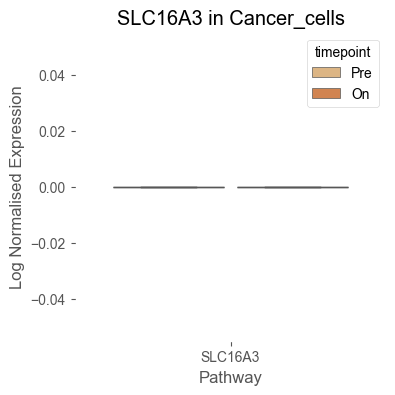

T-statistic: -3.722358877305901, P-value: 0.00019756530666874858
timepoint
On     0.755125
Pre    0.780921
Name: Flux, dtype: float64


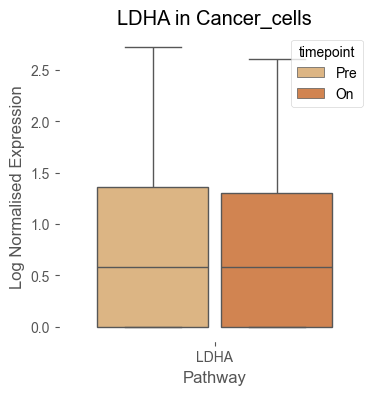

T-statistic: -8.501124240378052, P-value: 1.9235928964932702e-17
timepoint
On     0.170011
Pre    0.197536
Name: Flux, dtype: float64


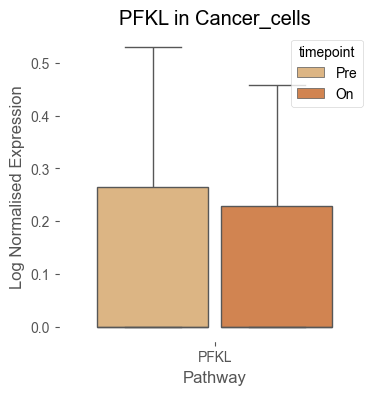

T-statistic: -0.7042538989009977, P-value: 0.481277629106291
timepoint
On     0.056122
Pre    0.057426
Name: Flux, dtype: float64


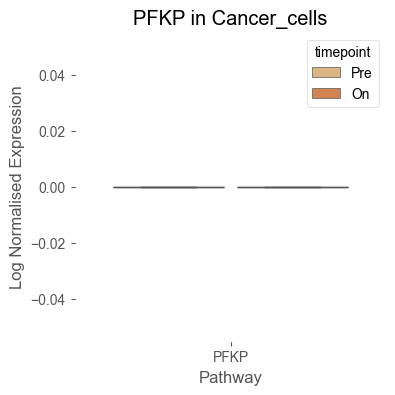

T-statistic: -8.137337646133394, P-value: 4.123726933996797e-16
timepoint
On     0.047350
Pre    0.062268
Name: Flux, dtype: float64


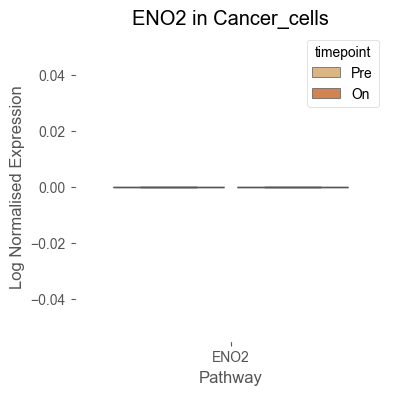

T-statistic: -5.996031398333473, P-value: 2.034448353908631e-09
timepoint
On     0.070495
Pre    0.083680
Name: Flux, dtype: float64


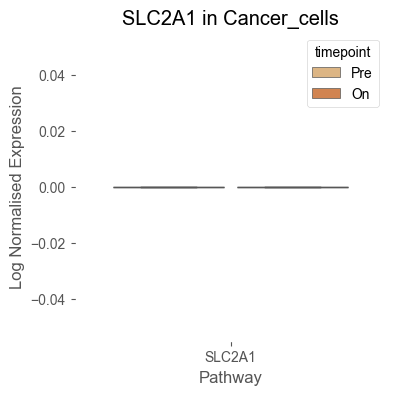

T-statistic: -6.344292882042537, P-value: 2.2516812490297503e-10
timepoint
On     0.037824
Pre    0.046948
Name: Flux, dtype: float64


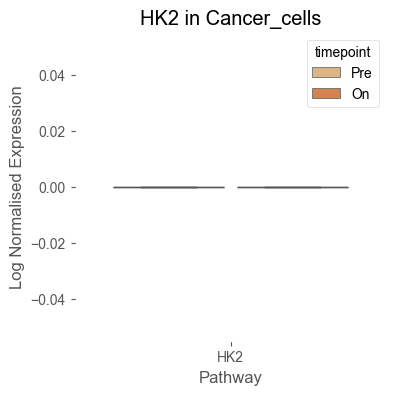

T-statistic: 19.747601345285787, P-value: 1.6707203427047233e-86
timepoint
On     0.443006
Pre    0.327019
Name: Flux, dtype: float64


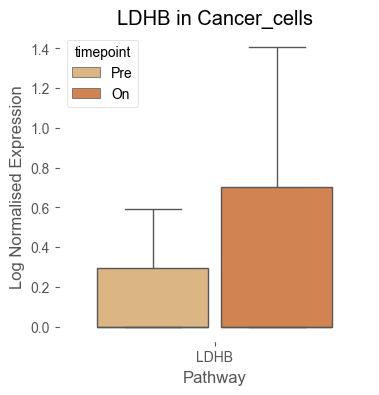

T-statistic: 13.705597161231976, P-value: 1.1035125831039824e-42
timepoint
On     1.430735
Pre    1.320511
Name: Flux, dtype: float64


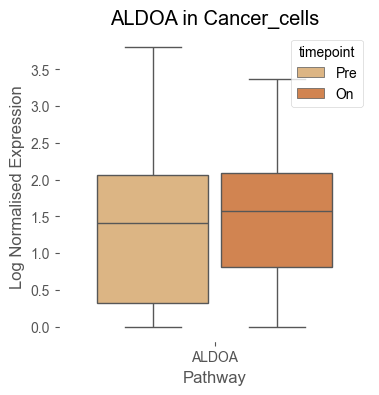

T-statistic: -1.9734860095969955, P-value: 0.04844517582635156
timepoint
On     0.025179
Pre    0.027664
Name: Flux, dtype: float64


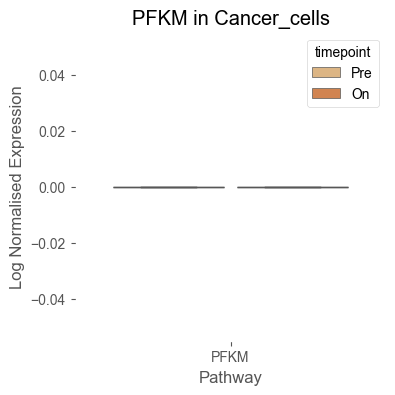

T-statistic: 4.219779022960689, P-value: 2.4493035650064956e-05
timepoint
On     0.338539
Pre    0.320437
Name: Flux, dtype: float64


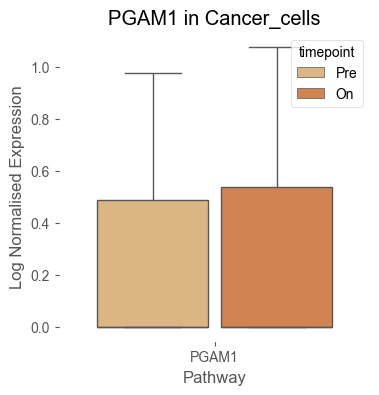

T-statistic: -6.540225757035898, P-value: 6.1958425540968e-11
timepoint
On     0.002475
Pre    0.005351
Name: Flux, dtype: float64


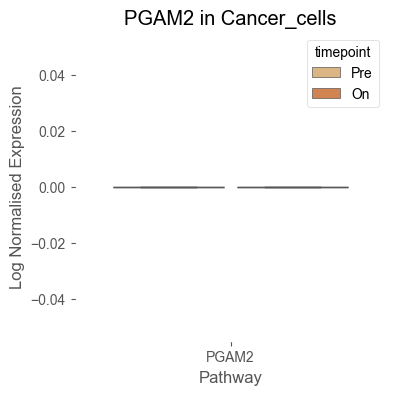

T-statistic: -5.522618699045965, P-value: 3.3547871080558967e-08
timepoint
On     0.008096
Pre    0.012015
Name: Flux, dtype: float64


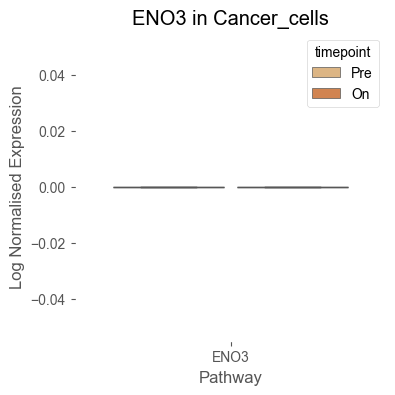

T-statistic: -6.670119598532454, P-value: 2.5798834455191277e-11
timepoint
On     0.455810
Pre    0.493297
Name: Flux, dtype: float64


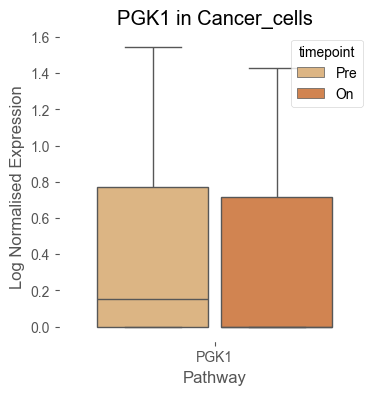

T-statistic: 5.302563268490287, P-value: 1.1462427452650967e-07
timepoint
On     0.937168
Pre    0.899987
Name: Flux, dtype: float64


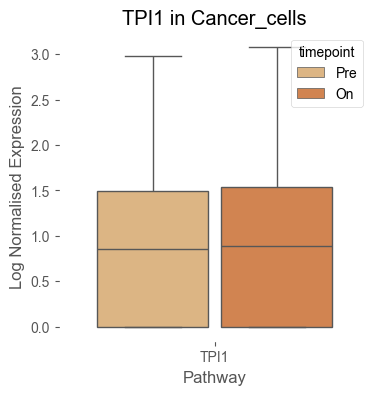

T-statistic: 0.26832042796415106, P-value: 0.7884536818191176
timepoint
On     0.017471
Pre    0.017197
Name: Flux, dtype: float64


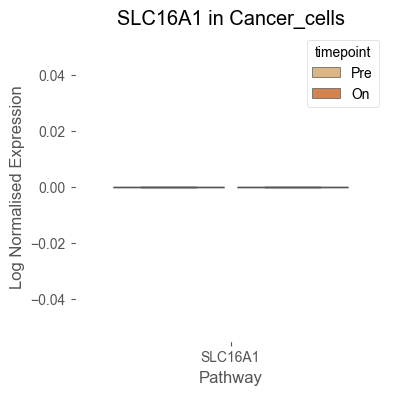

T-statistic: 7.60195346852854, P-value: 2.9627055510988844e-14
timepoint
On     0.511711
Pre    0.471302
Name: Flux, dtype: float64


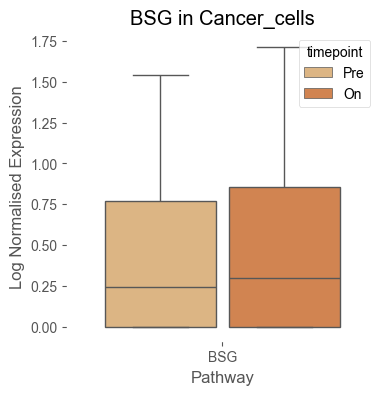

T-statistic: 12.262449312578548, P-value: 1.597322691883654e-34
timepoint
On     0.840456
Pre    0.758443
Name: Flux, dtype: float64


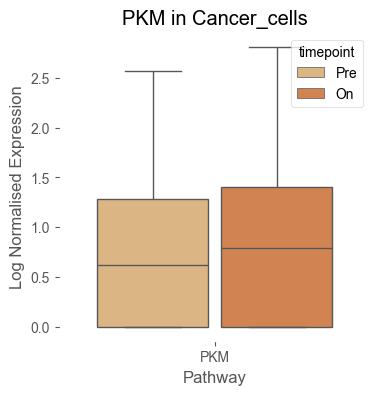

T-statistic: -0.03391463692646137, P-value: 0.972945343438841
timepoint
On     0.001228
Pre    0.001239
Name: Flux, dtype: float64


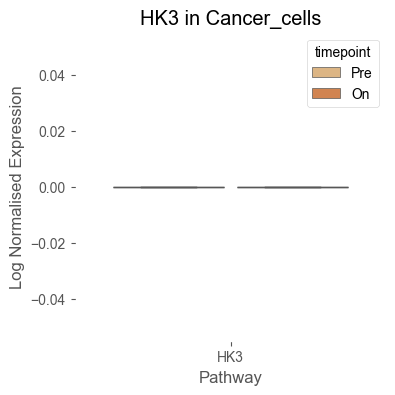

<Figure size 400x400 with 0 Axes>

In [ ]:
# Convert to dataframe to visualise
sc_ge = pd.DataFrame(data=adata.X.todense(), 
             index=adata.obs_names, columns=adata.var_names)
df_eda = pd.merge(sc_ge, cell_type, left_index=True, right_index=True)

cell_type_var = 'Cancer_cell'      #"B_cell"  #"Cancer_cell"  #
# pathway =  'Glycolysis_TCA' #'N-linked glycan synthesis' #'O-linked glycan synthesis' #
pathway_list= ['HK1' , 'LDHA']
for pathway in glyco_list:
    df_p =pd.melt(df_eda.query('`cellType` == @cell_type_var'), id_vars=[ 'timepoint'], 
                    value_vars=[pathway],
                    var_name='Pathway', value_name='Flux')

    # Performing t-test
    t_stat, p_value = stats.ttest_ind(df_p.query('timepoint =="On"')['Flux'], df_p.query('timepoint =="Pre"')['Flux'])

    print(f'T-statistic: {t_stat}, P-value: {p_value}')

    print(df_p.groupby('timepoint')['Flux'].mean())

    sns.boxplot(data=df_p,x ='Pathway', y='Flux', hue='timepoint', whis=1, fliersize=0,   gap=0.1, 
                hue_order =['Pre', 'On'], 
                palette=[ '#eab676', '#e67f3c', ],
                showfliers=False
                )
    plt.title(f'{pathway} in {cell_type_var}s')
    plt.ylabel('Log Normalised Expression')
    plt.savefig(f"Plot/Gene/Boxplot_{cell_type_var}_{pathway}.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre 22.3305    0.0       0.0   True
  E_On  NE_On 23.8364    0.0       0.0   True
  E_On NE_Pre 36.1941    0.0       0.0   True
 E_Pre  NE_On -3.8908 0.0001    0.0006   True
 E_Pre NE_Pre 13.0219    0.0       0.0   True
 NE_On NE_Pre 22.0702    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [8.39496890e-108 1.87434102e-123 2.01951252e-278 6.00751448e-004
 7.15261404e-038 1.64730573e-106]
expansion  timepoint
E          On           3.018118
           Pre          2.563350
NE         On           2.616219
           Pre          2.377339
Name: Flux, dtype: float64


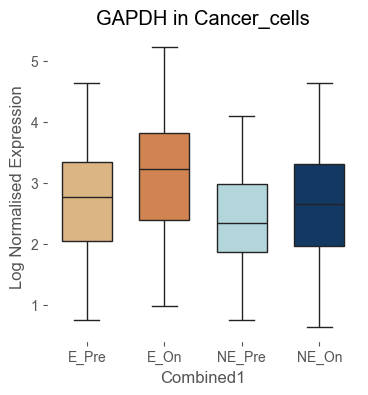

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre   2.0595 0.0395    0.2368  False
  E_On  NE_On  -9.3172    0.0       0.0   True
  E_On NE_Pre   -8.309    0.0       0.0   True
 E_Pre  NE_On -14.6064    0.0       0.0   True
 E_Pre NE_Pre -13.2406    0.0       0.0   True
 NE_On NE_Pre   1.8209 0.0686    0.4118  False
----------------------------------------------
P value -Bonferroni correction [2.36814499e-01 7.72477721e-20 6.09960086e-16 2.24716116e-47
 4.05541017e-39 4.11756089e-01]
expansion  timepoint
E          On           0.080958
           Pre          0.071054
NE         On           0.122074
           Pre          0.116991
Name: Flux, dtype: float64


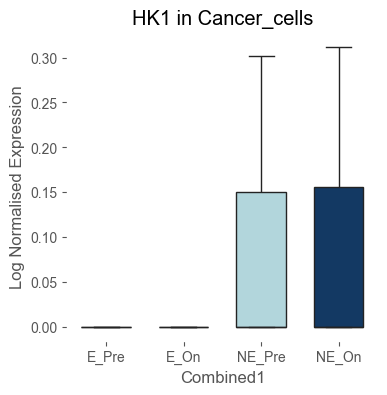

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre  -1.2455  0.213       1.0  False
  E_On  NE_On -10.1201    0.0       0.0   True
  E_On NE_Pre -11.5355    0.0       0.0   True
 E_Pre  NE_On -11.3368    0.0       0.0   True
 E_Pre NE_Pre -13.1023    0.0       0.0   True
 NE_On NE_Pre  -2.5218 0.0117    0.0701  False
----------------------------------------------
P value -Bonferroni correction [1.00000000e+00 2.99484141e-23 6.34086075e-30 5.95069803e-29
 2.50340337e-38 7.00749434e-02]
expansion  timepoint
E          On           0.027371
           Pre          0.031545
NE         On           0.064759
           Pre          0.071115
Name: Flux, dtype: float64


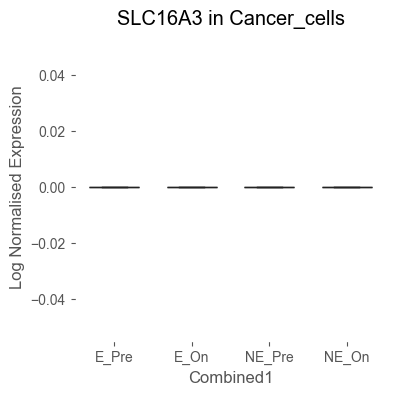

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre   4.901    0.0       0.0   True
  E_On  NE_On 21.5563    0.0       0.0   True
  E_On NE_Pre 20.3794    0.0       0.0   True
 E_Pre  NE_On 18.6087    0.0       0.0   True
 E_Pre NE_Pre 17.2543    0.0       0.0   True
 NE_On NE_Pre -1.0926 0.2746       1.0  False
---------------------------------------------
P value -Bonferroni correction [5.78584098e-006 2.22614679e-101 9.43195468e-091 4.45315409e-076
 1.38594976e-065 1.00000000e+000]
expansion  timepoint
E          On           0.985063
           Pre          0.903808
NE         On           0.713437
           Pre          0.721838
Name: Flux, dtype: float64


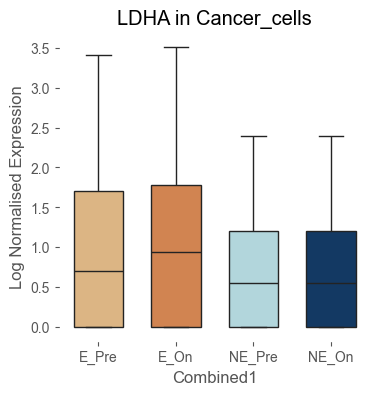

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -6.8413    0.0       0.0   True
  E_On  NE_On   4.408    0.0    0.0001   True
  E_On NE_Pre  4.0586    0.0    0.0003   True
 E_Pre  NE_On 16.6733    0.0       0.0   True
 E_Pre NE_Pre 15.9759    0.0       0.0   True
 NE_On NE_Pre -0.5708 0.5682       1.0  False
---------------------------------------------
P value -Bonferroni correction [4.90166233e-11 6.28379117e-05 2.97218299e-04 2.34758090e-61
 2.03149773e-56 1.00000000e+00]
expansion  timepoint
E          On           0.191389
           Pre          0.249706
NE         On           0.166557
           Pre          0.168478
Name: Flux, dtype: float64


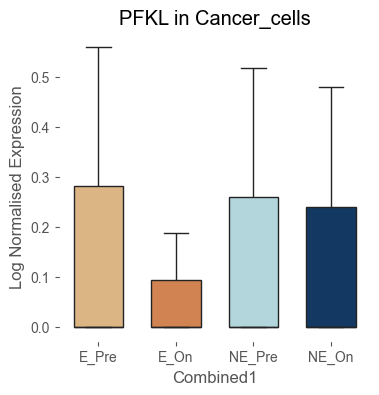

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat  pval pval_corr reject
-------------------------------------------
  E_On  E_Pre 13.1715  0.0       0.0   True
  E_On  NE_On 26.9117  0.0       0.0   True
  E_On NE_Pre 21.5945  0.0       0.0   True
 E_Pre  NE_On  9.5829  0.0       0.0   True
 E_Pre NE_Pre   4.423  0.0    0.0001   True
 NE_On NE_Pre -6.6363  0.0       0.0   True
-------------------------------------------
P value -Bonferroni correction [1.30995979e-038 1.45543635e-156 1.19900023e-101 6.08143343e-021
 5.86309473e-005 1.95445579e-010]
expansion  timepoint
E          On           0.132606
           Pre          0.062638
NE         On           0.039228
           Pre          0.050810
Name: Flux, dtype: float64


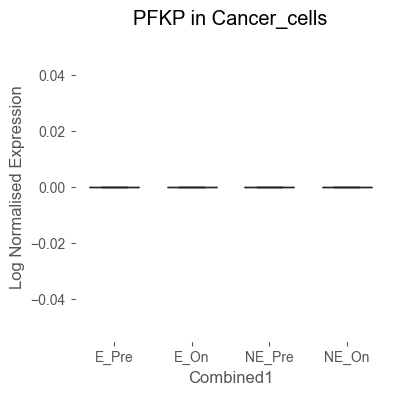

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  0.5572 0.5774       1.0  False
  E_On  NE_On -2.0221 0.0432    0.2591  False
  E_On NE_Pre -7.8634    0.0       0.0   True
 E_Pre  NE_On -3.2747 0.0011    0.0064   True
 E_Pre NE_Pre -10.432    0.0       0.0   True
 NE_On NE_Pre  -9.663    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [1.00000000e+00 2.59070840e-01 2.33931646e-14 6.35306318e-03
 1.18420333e-24 2.74949906e-21]
expansion  timepoint
E          On           0.043593
           Pre          0.041490
NE         On           0.050199
           Pre          0.071345
Name: Flux, dtype: float64


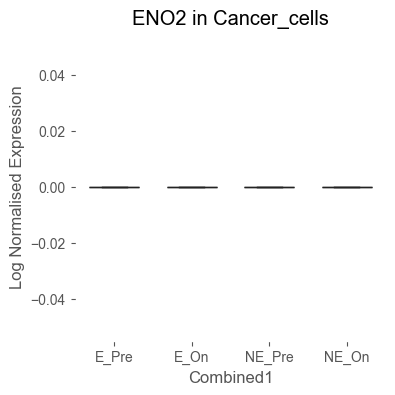

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre   0.4598 0.6457       1.0  False
  E_On  NE_On    -6.97    0.0       0.0   True
  E_On NE_Pre  -9.6543    0.0       0.0   True
 E_Pre  NE_On  -9.7107    0.0       0.0   True
 E_Pre NE_Pre -13.2208    0.0       0.0   True
 NE_On NE_Pre  -5.4461    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [1.00000000e+00 1.94810699e-11 3.10771587e-21 1.75676252e-21
 5.26627885e-39 3.10684722e-07]
expansion  timepoint
E          On           0.050809
           Pre          0.049142
NE         On           0.077926
           Pre          0.092607
Name: Flux, dtype: float64


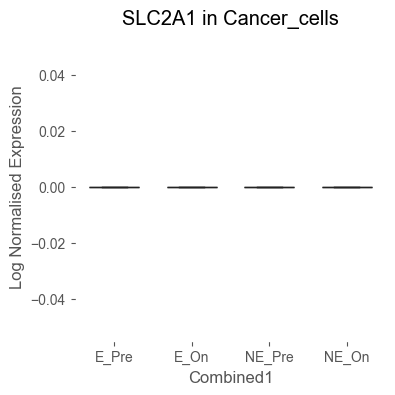

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre  -2.9128 0.0036    0.0215   True
  E_On  NE_On  -6.8059    0.0       0.0   True
  E_On NE_Pre -11.0812    0.0       0.0   True
 E_Pre  NE_On  -4.1386    0.0    0.0002   True
 E_Pre NE_Pre  -9.5904    0.0       0.0   True
 NE_On NE_Pre  -7.4762    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [2.15276367e-02 6.15772176e-11 1.09249632e-27 2.10256538e-04
 5.69274466e-21 4.68684542e-13]
expansion  timepoint
E          On           0.024478
           Pre          0.033214
NE         On           0.041992
           Pre          0.054842
Name: Flux, dtype: float64


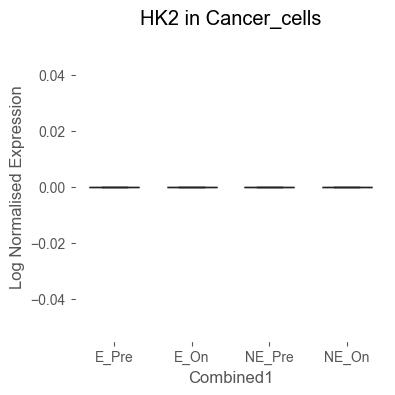

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat  pval pval_corr reject
-------------------------------------------
  E_On  E_Pre 28.4308  0.0       0.0   True
  E_On  NE_On 39.8946  0.0       0.0   True
  E_On NE_Pre 51.0318  0.0       0.0   True
 E_Pre  NE_On  5.1377  0.0       0.0   True
 E_Pre NE_Pre 16.7009  0.0       0.0   True
 NE_On NE_Pre 14.5247  0.0       0.0   True
-------------------------------------------
P value -Bonferroni correction [3.56934080e-172 0.00000000e+000 0.00000000e+000 1.67925984e-006
 1.56124381e-061 6.74159830e-047]
expansion  timepoint
E          On           0.780030
           Pre          0.380994
NE         On           0.338527
           Pre          0.251184
Name: Flux, dtype: float64


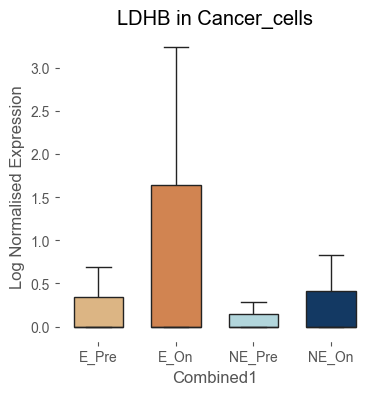

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval pval_corr reject
--------------------------------------------
  E_On  E_Pre -4.6852   0.0       0.0   True
  E_On  NE_On  3.2908 0.001     0.006   True
  E_On NE_Pre 20.9228   0.0       0.0   True
 E_Pre  NE_On 11.1542   0.0       0.0   True
 E_Pre NE_Pre 32.2156   0.0       0.0   True
 NE_On NE_Pre 28.3888   0.0       0.0   True
--------------------------------------------
P value -Bonferroni correction [1.69382054e-005 6.00134776e-003 1.50298542e-095 4.66975620e-028
 8.47653288e-223 9.89963705e-175]
expansion  timepoint
E          On           1.490970
           Pre          1.576618
NE         On           1.443054
           Pre          1.185464
Name: Flux, dtype: float64


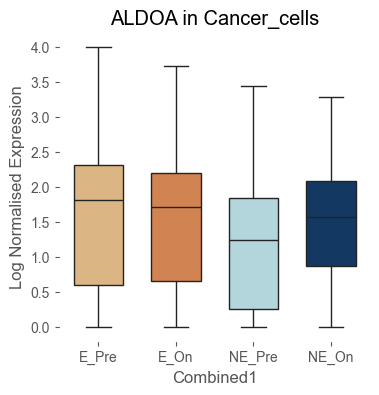

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -1.1781 0.2388       1.0  False
  E_On  NE_On  0.4892 0.6247       1.0  False
  E_On NE_Pre -0.0037 0.9971       1.0  False
 E_Pre  NE_On  2.4556 0.0141    0.0844  False
 E_Pre NE_Pre  1.8033 0.0714    0.4282  False
 NE_On NE_Pre -0.7908  0.429       1.0  False
---------------------------------------------
P value -Bonferroni correction [1.         1.         1.         0.08443023 0.42815187 1.        ]
expansion  timepoint
E          On           0.026020
           Pre          0.029526
NE         On           0.024917
           Pre          0.026028
Name: Flux, dtype: float64


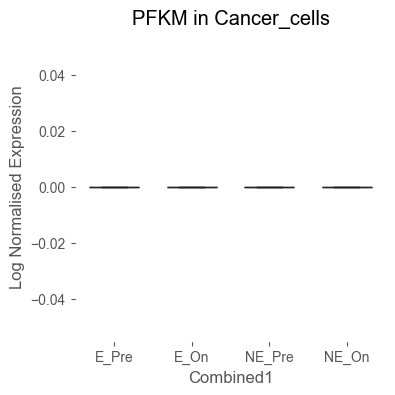

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  5.4852    0.0       0.0   True
  E_On  NE_On  4.8361    0.0       0.0   True
  E_On NE_Pre  7.6736    0.0       0.0   True
 E_Pre  NE_On -2.5594 0.0105    0.0629  False
 E_Pre NE_Pre  0.8201 0.4122       1.0  False
 NE_On NE_Pre  4.4947    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [2.52087990e-07 7.99050284e-06 1.04207315e-13 6.29358655e-02
 1.00000000e+00 4.19278102e-05]
expansion  timepoint
E          On           0.374094
           Pre          0.318912
NE         On           0.335317
           Pre          0.313689
Name: Flux, dtype: float64


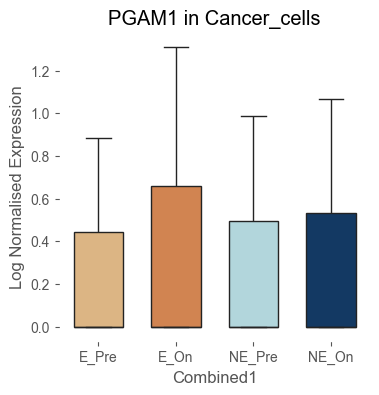

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre   3.0092 0.0026    0.0157   True
  E_On  NE_On   5.0822    0.0       0.0   True
  E_On NE_Pre  -1.4109 0.1583    0.9497  False
 E_Pre  NE_On   0.7147 0.4748       1.0  False
 E_Pre NE_Pre  -6.8188    0.0       0.0   True
 NE_On NE_Pre -11.1284    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [1.57440969e-02 2.25374485e-06 9.49705889e-01 1.00000000e+00
 5.62212795e-11 6.04441793e-28]
expansion  timepoint
E          On           0.005549
           Pre          0.002150
NE         On           0.001804
           Pre          0.007001
Name: Flux, dtype: float64


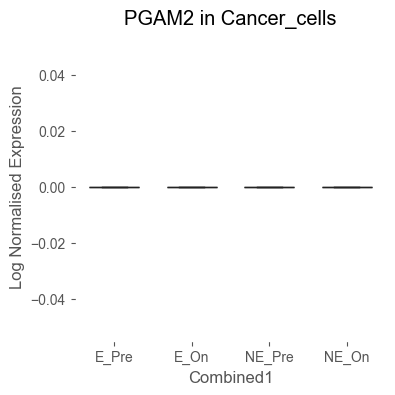

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -3.4112 0.0006    0.0039   True
  E_On  NE_On -3.2487 0.0012     0.007   True
  E_On NE_Pre -6.0175    0.0       0.0   True
 E_Pre  NE_On  2.4472 0.0144    0.0864  False
 E_Pre NE_Pre -0.6374 0.5239       1.0  False
 NE_On NE_Pre  -4.739    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [3.89196157e-03 6.96454113e-03 1.07829513e-08 8.64185307e-02
 1.00000000e+00 1.29329764e-05]
expansion  timepoint
E          On           0.005324
           Pre          0.011781
NE         On           0.008978
           Pre          0.012558
Name: Flux, dtype: float64


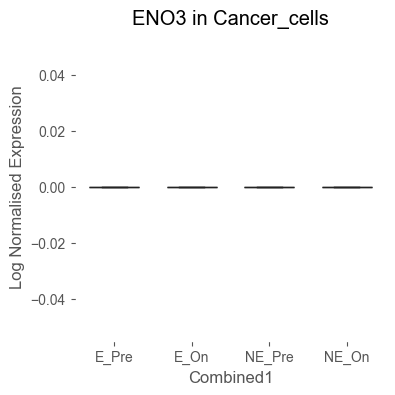

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  3.0328 0.0024    0.0146   True
  E_On  NE_On  13.428    0.0       0.0   True
  E_On NE_Pre   9.852    0.0       0.0   True
 E_Pre  NE_On 11.5422    0.0       0.0   True
 E_Pre NE_Pre   7.269    0.0       0.0   True
 NE_On NE_Pre -5.3402    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [1.45646321e-02 3.42039057e-40 4.46326426e-22 5.63586863e-30
 2.23020601e-12 5.60012843e-07]
expansion  timepoint
E          On           0.575429
           Pre          0.534333
NE         On           0.438198
           Pre          0.471605
Name: Flux, dtype: float64


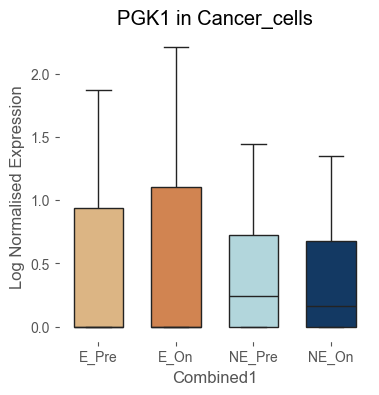

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat  pval pval_corr reject
-------------------------------------------
  E_On  E_Pre 15.8682  0.0       0.0   True
  E_On  NE_On 24.2376  0.0       0.0   True
  E_On NE_Pre 27.6778  0.0       0.0   True
 E_Pre  NE_On  4.9703  0.0       0.0   True
 E_Pre NE_Pre  9.1857  0.0       0.0   True
 NE_On NE_Pre  5.7006  0.0       0.0   True
-------------------------------------------
P value -Bonferroni correction [1.92897848e-055 1.47724280e-127 3.52483660e-165 4.03274512e-006
 2.62039124e-019 7.21619892e-008]
expansion  timepoint
E          On           1.204384
           Pre          0.942677
NE         On           0.891549
           Pre          0.847426
Name: Flux, dtype: float64


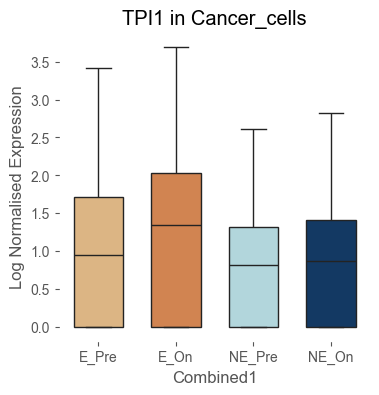

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  6.1225    0.0       0.0   True
  E_On  NE_On 13.1086    0.0       0.0   True
  E_On NE_Pre  9.5498    0.0       0.0   True
 E_Pre  NE_On  5.7297    0.0       0.0   True
 E_Pre NE_Pre   2.663 0.0077    0.0465   True
 NE_On NE_Pre -3.2434 0.0012    0.0071   True
---------------------------------------------
P value -Bonferroni correction [5.67475625e-09 2.35623164e-38 8.53287133e-21 6.09350869e-08
 4.64909883e-02 7.09329701e-03]
expansion  timepoint
E          On           0.036407
           Pre          0.020000
NE         On           0.012323
           Pre          0.015803
Name: Flux, dtype: float64


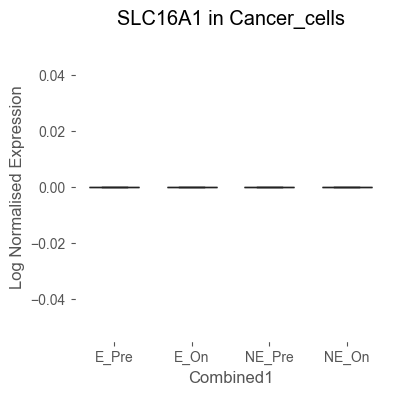

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  0.0615 0.9509       1.0  False
  E_On  NE_On  8.9849    0.0       0.0   True
  E_On NE_Pre 17.9948    0.0       0.0   True
 E_Pre  NE_On 10.8905    0.0       0.0   True
 E_Pre NE_Pre 21.3551    0.0       0.0   True
 NE_On NE_Pre 13.7787    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [1.00000000e+00 1.65774338e-18 3.89696826e-71 8.65045905e-27
 1.35098059e-99 2.58705715e-42]
expansion  timepoint
E          On           0.591305
           Pre          0.590474
NE         On           0.501125
           Pre          0.422128
Name: Flux, dtype: float64


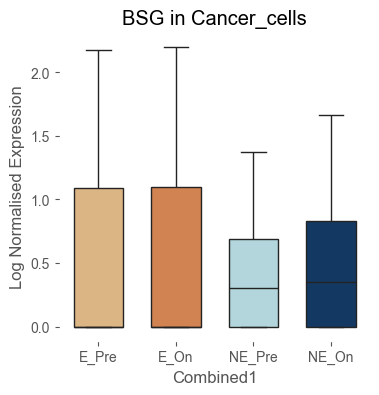

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre   0.2539 0.7995       1.0  False
  E_On  NE_On  -7.8212    0.0       0.0   True
  E_On NE_Pre   1.6848  0.092    0.5522  False
 E_Pre  NE_On -10.1092    0.0       0.0   True
 E_Pre NE_Pre   1.6891 0.0912    0.5472  False
 NE_On NE_Pre  15.3686    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [1.00000000e+00 3.25955233e-14 5.52208587e-01 3.29818604e-23
 5.47243628e-01 2.27897587e-52]
expansion  timepoint
E          On           0.777999
           Pre          0.774185
NE         On           0.875950
           Pre          0.757261
Name: Flux, dtype: float64


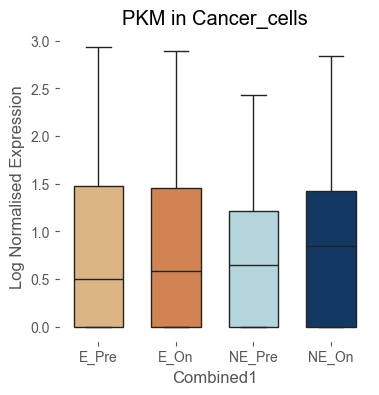

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -0.1208 0.9039       1.0  False
  E_On  NE_On  0.7866 0.4315       1.0  False
  E_On NE_Pre  1.0323 0.3019       1.0  False
 E_Pre  NE_On  1.0697 0.2848       1.0  False
 E_Pre NE_Pre  1.3103 0.1901       1.0  False
 NE_On NE_Pre  0.4938 0.6214       1.0  False
---------------------------------------------
P value -Bonferroni correction [1. 1. 1. 1. 1. 1.]
expansion  timepoint
E          On           0.001627
           Pre          0.001746
NE         On           0.001195
           Pre          0.001045
Name: Flux, dtype: float64


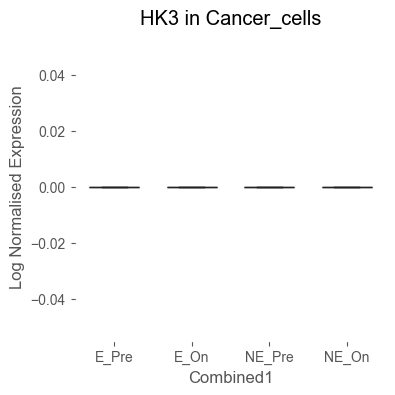

<Figure size 400x400 with 0 Axes>

In [87]:

cell_type_var = "Cancer_cell"  # "T_cell"  #
# pathway_list =['GALM']

# pathway_list= ['Glycolysis_TCA' ,  'N-linked glycan synthesis', 'Serine metabolism', 'Fatty acids metabolism']
df_eda_exp = df_eda.dropna(axis=0)
for pathway in glyco_list:
    df_p =pd.melt(df_eda_exp.query('`cellType` == @cell_type_var'), id_vars=['expansion', 'timepoint'], 
                    value_vars=[pathway],
                    var_name='Pathway', value_name='Flux')

    # Performing t-test
    df_p['Combined1'] = df_p['expansion'] +"_" + df_p['timepoint'] 
    # Performing t-test
    comp1 = mc.MultiComparison(df_p['Flux'], df_p['Combined1'])

    tbl, a1, a2 = comp1.allpairtest(stats.ttest_ind, method= "bonf")
    print(tbl)
    print('P value -Bonferroni correction',a1[2])

    print(df_p.groupby(['expansion','timepoint'])['Flux'].mean())

    sns.boxplot(data=df_p,x ='Combined1', y='Flux', hue='Combined1', whis=1, fliersize=0,   gap=0.2, 
                hue_order =['E_Pre', 'E_On', 'NE_Pre', 'NE_On'], 
                palette=['#eab676', '#e67f3c', '#abdbe3', '#063970' ],
                showfliers=False
                )
    plt.title(f'{pathway} in {cell_type_var}s')
    plt.ylabel('Log Normalised Expression')
    plt.savefig(f"Plot/GeneExpansion_{cell_type_var}_{pathway}.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre   2.681 0.0074    0.0442   True
  E_On  NE_On  4.0455 0.0001    0.0003   True
  E_On NE_Pre  1.2205 0.2223       1.0  False
 E_Pre  NE_On  1.1107 0.2667       1.0  False
 E_Pre NE_Pre -1.5682 0.1169    0.7013  False
 NE_On NE_Pre -2.8694 0.0041    0.0248   True
---------------------------------------------
P value -Bonferroni correction [4.41665968e-02 3.17264028e-04 1.00000000e+00 1.00000000e+00
 7.01289153e-01 2.47647955e-02]
expansion  timepoint
E          On           1.351218
           Pre          1.290697
NE         On           1.264771
           Pre          1.326126
Name: Flux, dtype: float64


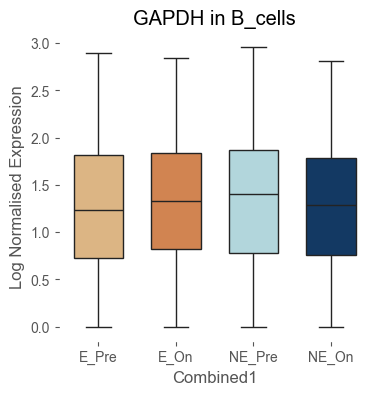

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  2.8887 0.0039    0.0233   True
  E_On  NE_On -1.3847 0.1662    0.9972  False
  E_On NE_Pre -1.2576 0.2086       1.0  False
 E_Pre  NE_On  -3.947 0.0001    0.0005   True
 E_Pre NE_Pre -3.8398 0.0001    0.0007   True
 NE_On NE_Pre  0.1462 0.8838       1.0  False
---------------------------------------------
P value -Bonferroni correction [2.33019804e-02 9.97173133e-01 1.00000000e+00 4.81250643e-04
 7.46841922e-04 1.00000000e+00]
expansion  timepoint
E          On           0.050430
           Pre          0.036284
NE         On           0.057486
           Pre          0.056691
Name: Flux, dtype: float64


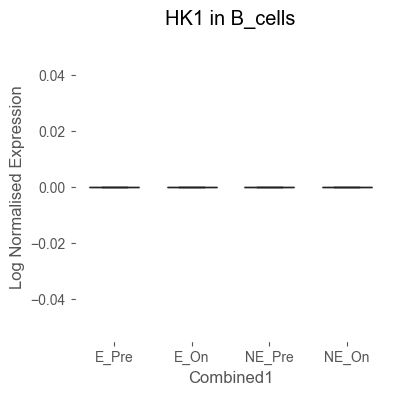

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  2.5746 0.0101    0.0604  False
  E_On  NE_On  3.4289 0.0006    0.0037   True
  E_On NE_Pre  1.1443 0.2525       1.0  False
 E_Pre  NE_On  0.7507 0.4529       1.0  False
 E_Pre NE_Pre -1.4262 0.1539    0.9231  False
 NE_On NE_Pre -2.2334 0.0256    0.1534  False
---------------------------------------------
P value -Bonferroni correction [0.06037341 0.00366114 1.         1.         0.92313011 0.15335436]
expansion  timepoint
E          On           0.052473
           Pre          0.040745
NE         On           0.037263
           Pre          0.047430
Name: Flux, dtype: float64


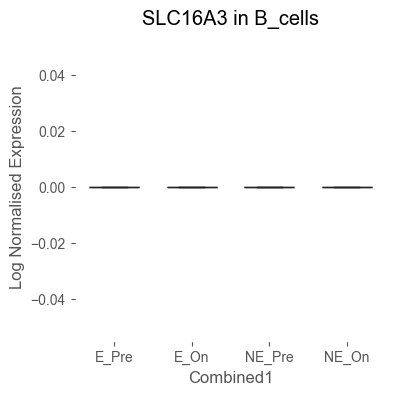

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  0.4644 0.6423       1.0  False
  E_On  NE_On  3.4898 0.0005    0.0029   True
  E_On NE_Pre  1.4478 0.1477    0.8864  False
 E_Pre  NE_On  2.7118 0.0067    0.0403   True
 E_Pre NE_Pre  0.8534 0.3935       1.0  False
 NE_On NE_Pre -1.9916 0.0465    0.2788  False
---------------------------------------------
P value -Bonferroni correction [1.         0.00292154 0.88641256 0.04029195 1.         0.27878656]
expansion  timepoint
E          On           0.303831
           Pre          0.298171
NE         On           0.263249
           Pre          0.287335
Name: Flux, dtype: float64


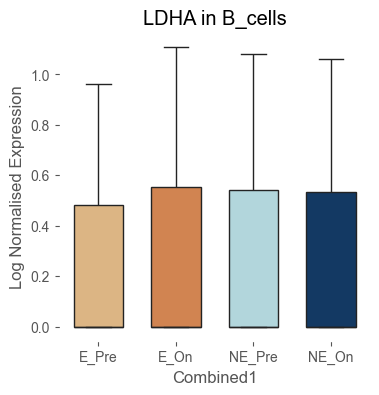

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  2.3227 0.0202    0.1214  False
  E_On  NE_On  -0.882 0.3778       1.0  False
  E_On NE_Pre -2.6099 0.0091    0.0545  False
 E_Pre  NE_On -2.9958 0.0028    0.0165   True
 E_Pre NE_Pre -4.5707    0.0       0.0   True
 NE_On NE_Pre -1.6022 0.1092     0.655  False
---------------------------------------------
P value -Bonferroni correction [1.21388863e-01 1.00000000e+00 5.44667600e-02 1.65019154e-02
 2.98020527e-05 6.54981735e-01]
expansion  timepoint
E          On           0.127145
           Pre          0.109022
NE         On           0.134031
           Pre          0.147348
Name: Flux, dtype: float64


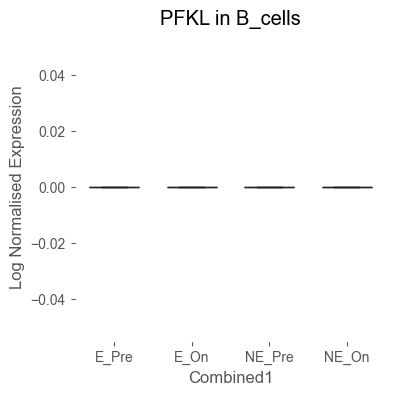

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  2.5455 0.0109    0.0656  False
  E_On  NE_On -1.4207 0.1555    0.9327  False
  E_On NE_Pre -0.0633 0.9495       1.0  False
 E_Pre  NE_On -3.8379 0.0001    0.0008   True
 E_Pre NE_Pre -2.4517 0.0142    0.0855  False
 NE_On NE_Pre  1.2912 0.1967       1.0  False
---------------------------------------------
P value -Bonferroni correction [6.56417900e-02 9.32734723e-01 1.00000000e+00 7.53446452e-04
 8.54896329e-02 1.00000000e+00]
expansion  timepoint
E          On           0.038212
           Pre          0.027284
NE         On           0.044560
           Pre          0.038492
Name: Flux, dtype: float64


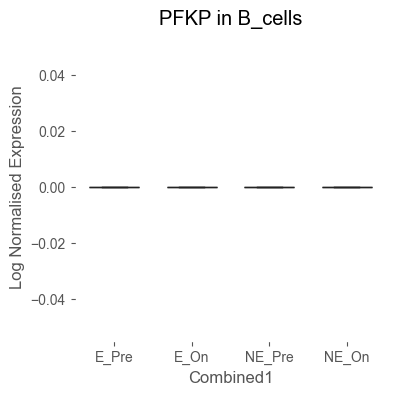

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  2.6344 0.0085    0.0507  False
  E_On  NE_On  1.5853  0.113    0.6777  False
  E_On NE_Pre -0.3775 0.7058       1.0  False
 E_Pre  NE_On  -1.049 0.2942       1.0  False
 E_Pre NE_Pre -2.7775 0.0055     0.033   True
 NE_On NE_Pre -1.8357 0.0665    0.3987  False
---------------------------------------------
P value -Bonferroni correction [0.05071598 0.67771352 1.         1.         0.0329802  0.39871022]
expansion  timepoint
E          On           0.034767
           Pre          0.024654
NE         On           0.028694
           Pre          0.036281
Name: Flux, dtype: float64


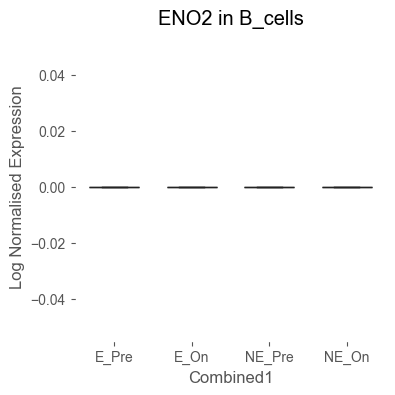

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  0.7376 0.4608       1.0  False
  E_On  NE_On  -1.815 0.0696    0.4174  False
  E_On NE_Pre -2.6434 0.0082    0.0494   True
 E_Pre  NE_On -2.4151 0.0158    0.0946  False
 E_Pre NE_Pre -3.1639 0.0016    0.0094   True
 NE_On NE_Pre  -0.755 0.4503       1.0  False
---------------------------------------------
P value -Bonferroni correction [1.         0.41744091 0.04937349 0.09458991 0.00939121 1.        ]
expansion  timepoint
E          On           0.029762
           Pre          0.026789
NE         On           0.037083
           Pre          0.040280
Name: Flux, dtype: float64


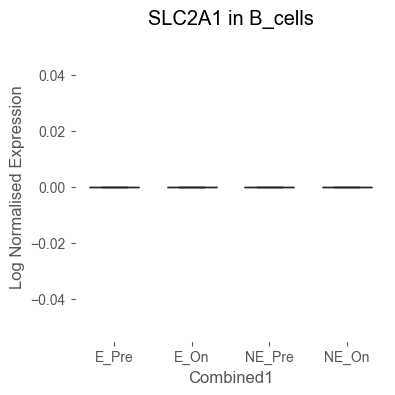

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2  stat   pval  pval_corr reject
--------------------------------------------
  E_On  E_Pre 0.3287 0.7424       1.0  False
  E_On  NE_On 1.4579 0.1449    0.8696  False
  E_On NE_Pre  1.019 0.3082       1.0  False
 E_Pre  NE_On 1.0737  0.283       1.0  False
 E_Pre NE_Pre 0.6397 0.5224       1.0  False
 NE_On NE_Pre -0.365 0.7151       1.0  False
--------------------------------------------
P value -Bonferroni correction [1.         0.86960804 1.         1.         1.         1.        ]
expansion  timepoint
E          On           0.007552
           Pre          0.006930
NE         On           0.005071
           Pre          0.005702
Name: Flux, dtype: float64


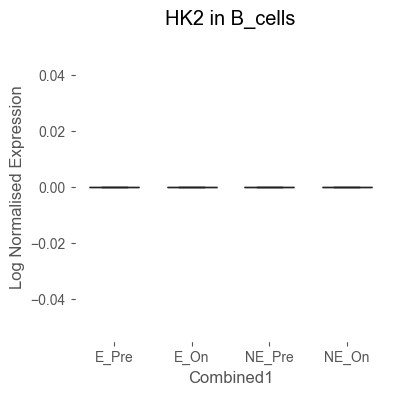

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  5.5296    0.0       0.0   True
  E_On  NE_On  2.1784 0.0294    0.1765  False
  E_On NE_Pre -2.4362 0.0149    0.0892  False
 E_Pre  NE_On -3.2097 0.0013     0.008   True
 E_Pre NE_Pre -7.5265    0.0       0.0   True
 NE_On NE_Pre -4.3869    0.0    0.0001   True
---------------------------------------------
P value -Bonferroni correction [2.01404073e-07 1.76494093e-01 8.92052128e-02 8.02085583e-03
 3.62460922e-13 7.01865985e-05]
expansion  timepoint
E          On           0.372665
           Pre          0.301771
NE         On           0.344725
           Pre          0.403745
Name: Flux, dtype: float64


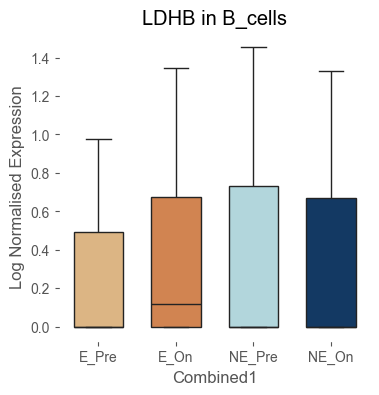

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -4.6604    0.0       0.0   True
  E_On  NE_On  1.6873 0.0916    0.5496  False
  E_On NE_Pre -6.1699    0.0       0.0   True
 E_Pre  NE_On  5.8319    0.0       0.0   True
 E_Pre NE_Pre -0.9202 0.3575       1.0  False
 NE_On NE_Pre -7.3709    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [1.93764055e-05 5.49616739e-01 4.35064703e-09 3.49079987e-08
 1.00000000e+00 1.15577110e-12]
expansion  timepoint
E          On           0.551836
           Pre          0.626628
NE         On           0.526930
           Pre          0.642259
Name: Flux, dtype: float64


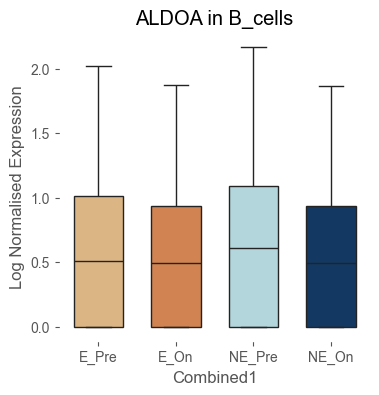

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  0.8247 0.4095       1.0  False
  E_On  NE_On -1.1892 0.2344       1.0  False
  E_On NE_Pre  0.2757 0.7828       1.0  False
 E_Pre  NE_On -1.8466 0.0649    0.3892  False
 E_Pre NE_Pre  -0.589 0.5559       1.0  False
 NE_On NE_Pre   1.464 0.1432    0.8595  False
---------------------------------------------
P value -Bonferroni correction [1.         1.         1.         0.38919306 1.         0.85946278]
expansion  timepoint
E          On           0.012537
           Pre          0.010511
NE         On           0.015747
           Pre          0.011905
Name: Flux, dtype: float64


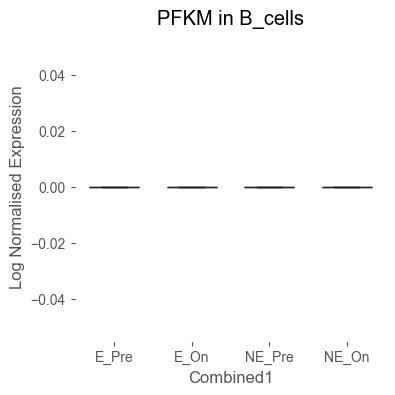

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  1.1641 0.2444       1.0  False
  E_On  NE_On  2.4599 0.0139    0.0836  False
  E_On NE_Pre  1.7899 0.0735    0.4411  False
 E_Pre  NE_On  1.1689 0.2425       1.0  False
 E_Pre NE_Pre  0.4884 0.6253       1.0  False
 NE_On NE_Pre -0.7546 0.4505       1.0  False
---------------------------------------------
P value -Bonferroni correction [1.         0.08355351 0.44111159 1.         1.         1.        ]
expansion  timepoint
E          On           0.249756
           Pre          0.237480
NE         On           0.224633
           Pre          0.232333
Name: Flux, dtype: float64


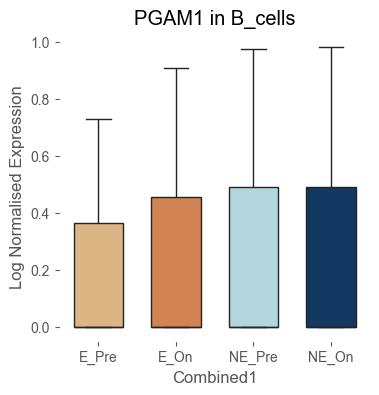

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -0.7224 0.4701       1.0  False
  E_On  NE_On -0.1546 0.8772       1.0  False
  E_On NE_Pre -2.0853 0.0371    0.2225  False
 E_Pre  NE_On  0.5701 0.5686       1.0  False
 E_Pre NE_Pre  -1.575 0.1153    0.6919  False
 NE_On NE_Pre -1.8948 0.0582     0.349  False
---------------------------------------------
P value -Bonferroni correction [1.         1.         0.22247206 1.         0.69187357 0.34897492]
expansion  timepoint
E          On           0.000185
           Pre          0.000374
NE         On           0.000210
           Pre          0.002018
Name: Flux, dtype: float64


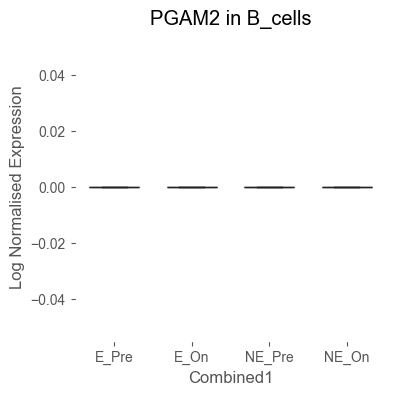

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  0.0056 0.9955       1.0  False
  E_On  NE_On  0.9514 0.3414       1.0  False
  E_On NE_Pre  0.0867 0.9309       1.0  False
 E_Pre  NE_On  0.9305 0.3521       1.0  False
 E_Pre NE_Pre  0.0773 0.9384       1.0  False
 NE_On NE_Pre -0.8945 0.3711       1.0  False
---------------------------------------------
P value -Bonferroni correction [1. 1. 1. 1. 1. 1.]
expansion  timepoint
E          On           0.007834
           Pre          0.007823
NE         On           0.006094
           Pre          0.007674
Name: Flux, dtype: float64


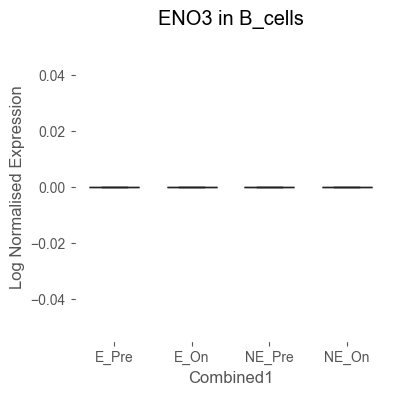

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat    pval  pval_corr reject
----------------------------------------------
  E_On  E_Pre   4.3839    0.0    0.0001   True
  E_On  NE_On   -3.166 0.0016    0.0093   True
  E_On NE_Pre  -8.3289    0.0       0.0   True
 E_Pre  NE_On  -7.0677    0.0       0.0   True
 E_Pre NE_Pre -11.6614    0.0       0.0   True
 NE_On NE_Pre  -4.8217    0.0       0.0   True
----------------------------------------------
P value -Bonferroni correction [7.12199489e-05 9.31910614e-03 5.92976159e-16 1.07317700e-11
 2.75558649e-30 8.75394365e-06]
expansion  timepoint
E          On           0.274076
           Pre          0.226255
NE         On           0.309699
           Pre          0.369591
Name: Flux, dtype: float64


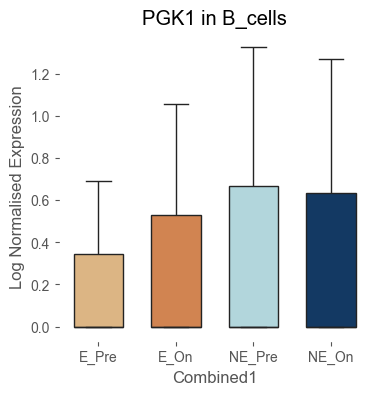

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  1.6476 0.0995    0.5969  False
  E_On  NE_On  1.5827 0.1135    0.6813  False
  E_On NE_Pre  -0.202 0.8399       1.0  False
 E_Pre  NE_On -0.1257    0.9       1.0  False
 E_Pre NE_Pre  -1.785 0.0743    0.4459  False
 NE_On NE_Pre -1.7328 0.0832    0.4991  False
---------------------------------------------
P value -Bonferroni correction [0.59690278 0.68129655 1.         1.         0.44587916 0.4990767 ]
expansion  timepoint
E          On           0.421914
           Pre          0.398758
NE         On           0.400610
           Pre          0.424563
Name: Flux, dtype: float64


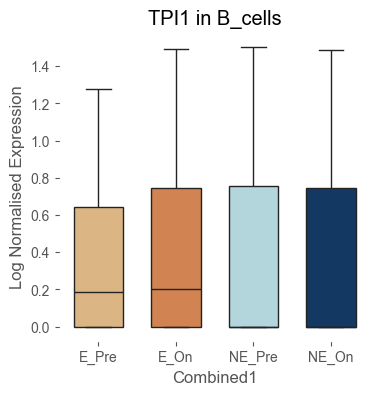

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  1.5185 0.1289    0.7736  False
  E_On  NE_On  2.4628 0.0138    0.0829  False
  E_On NE_Pre  0.6086 0.5428       1.0  False
 E_Pre  NE_On  0.9622  0.336       1.0  False
 E_Pre NE_Pre  -0.846 0.3976       1.0  False
 NE_On NE_Pre -1.7378 0.0823    0.4938  False
---------------------------------------------
P value -Bonferroni correction [0.7736406  0.08289084 1.         1.         1.         0.49383746]
expansion  timepoint
E          On           0.014779
           Pre          0.011232
NE         On           0.009197
           Pre          0.013296
Name: Flux, dtype: float64


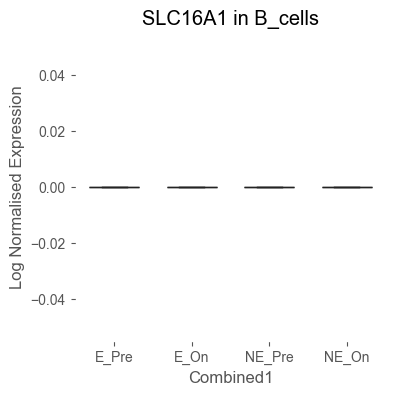

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -1.7785 0.0754    0.4523  False
  E_On  NE_On  6.6768    0.0       0.0   True
  E_On NE_Pre  6.2211    0.0       0.0   True
 E_Pre  NE_On  7.6133    0.0       0.0   True
 E_Pre NE_Pre  7.2418    0.0       0.0   True
 NE_On NE_Pre -0.6264 0.5311       1.0  False
---------------------------------------------
P value -Bonferroni correction [4.52282051e-01 1.59945559e-10 3.14821279e-09 1.90038855e-13
 3.01766452e-12 1.00000000e+00]
expansion  timepoint
E          On           0.241420
           Pre          0.259300
NE         On           0.181027
           Pre          0.186679
Name: Flux, dtype: float64


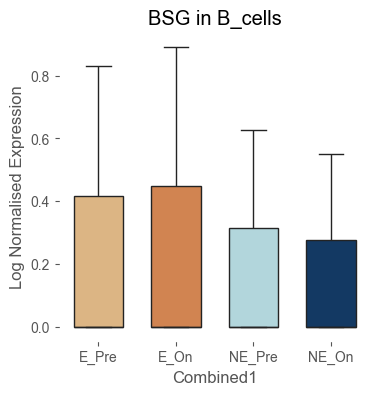

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre  4.4875    0.0       0.0   True
  E_On  NE_On  0.6322 0.5273       1.0  False
  E_On NE_Pre -4.7393    0.0       0.0   True
 E_Pre  NE_On  -3.751 0.0002    0.0011   True
 E_Pre NE_Pre -8.6497    0.0       0.0   True
 NE_On NE_Pre  -5.133    0.0       0.0   True
---------------------------------------------
P value -Bonferroni correction [4.41186964e-05 1.00000000e+00 1.31478370e-05 1.06842610e-03
 3.99942585e-17 1.76508862e-06]
expansion  timepoint
E          On           0.336080
           Pre          0.277078
NE         On           0.327899
           Pre          0.398168
Name: Flux, dtype: float64


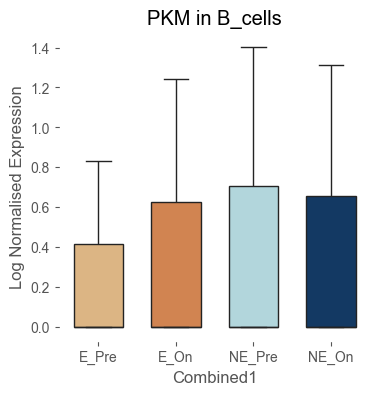

Test Multiple Comparison ttest_ind 
FWER=0.05 method=bonf
alphacSidak=0.01, alphacBonf=0.008
group1 group2   stat   pval  pval_corr reject
---------------------------------------------
  E_On  E_Pre -0.2187 0.8269       1.0  False
  E_On  NE_On  1.2119 0.2256       1.0  False
  E_On NE_Pre  1.3193 0.1871       1.0  False
 E_Pre  NE_On  1.3762 0.1688       1.0  False
 E_Pre NE_Pre  1.4981 0.1342     0.805  False
 NE_On NE_Pre     nan    nan       nan  False
---------------------------------------------
P value -Bonferroni correction [1.         1.         1.         1.         0.80500619        nan]
expansion  timepoint
E          On           0.000105
           Pre          0.000133
NE         On           0.000000
           Pre          0.000000
Name: Flux, dtype: float64


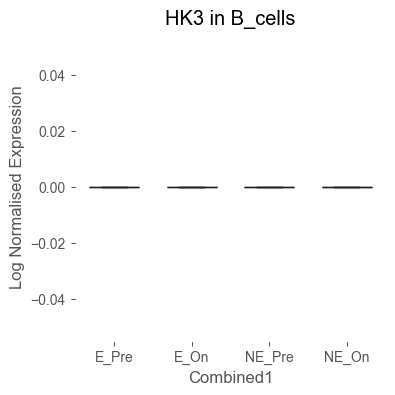

<Figure size 400x400 with 0 Axes>

In [89]:

cell_type_var = "B_cell"  # "T_cell"  #
# pathway_list =['GALM']

# pathway_list= ['Glycolysis_TCA' ,  'N-linked glycan synthesis', 'Serine metabolism', 'Fatty acids metabolism']
df_eda_exp = df_eda.dropna(axis=0)
for pathway in glyco_list:
    df_p =pd.melt(df_eda_exp.query('`cellType` == @cell_type_var'), id_vars=['expansion', 'timepoint'], 
                    value_vars=[pathway],
                    var_name='Pathway', value_name='Flux')

    # Performing t-test
    df_p['Combined1'] = df_p['expansion'] +"_" + df_p['timepoint'] 
    # Performing t-test
    comp1 = mc.MultiComparison(df_p['Flux'], df_p['Combined1'])

    tbl, a1, a2 = comp1.allpairtest(stats.ttest_ind, method= "bonf")
    print(tbl)
    print('P value -Bonferroni correction',a1[2])

    print(df_p.groupby(['expansion','timepoint'])['Flux'].mean())

    sns.boxplot(data=df_p,x ='Combined1', y='Flux', hue='Combined1', whis=1, fliersize=0,   gap=0.2, 
                hue_order =['E_Pre', 'E_On', 'NE_Pre', 'NE_On'], 
                palette=['#eab676', '#e67f3c', '#abdbe3', '#063970' ],
                showfliers=False
                )
    plt.title(f'{pathway} in {cell_type_var}s')
    plt.ylabel('Log Normalised Expression')
    plt.savefig(f"Plot/GeneExpansion_{cell_type_var}_{pathway}.pdf", bbox_inches='tight')
    plt.show()
    plt.clf()